# Master Notebook: Climate-Induced Yield Volatility in European Crops

This Kaggle-ready master notebook runs the complete workflow for **RQ1–RQ7** using four model families throughout:

- Linear Regression / Logistic Regression
- Random Forest
- XGBoost
- LSTM

It builds the final merged dataset from the attached Kaggle inputs:

1. **Climate Change: Earth Surface Temperature Data**
2. **FAOSTAT Crops and Livestock Data**

Then it saves all outputs to:

`/kaggle/working/outputs/`

and finally creates:

`/kaggle/working/all_rq_outputs_all_models.zip`

In [2]:
# =============================
# 0. Imports and global settings
# =============================

import os
import glob
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("XGBoost not available. XGBoost models will be skipped.", e)

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    HAS_TF = True
except Exception as e:
    HAS_TF = False
    print("TensorFlow not available. LSTM models will be skipped.", e)

SEED = 42
np.random.seed(SEED)

OUTPUT_ROOT = Path("/kaggle/working/outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path("/kaggle/working/final_europe_crop_dataset.csv")

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def save_table(df, out_dir, name):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_dir / f"{name}.csv", index=False)
    try:
        df.to_latex(out_dir / f"{name}.tex", index=False)
    except Exception:
        pass

def save_current_fig(out_dir, name):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_dir / f"{name}.pdf")
    plt.savefig(out_dir / f"{name}.png")
    plt.show()

def normalize_series(x):
    x = pd.Series(x).astype(float)
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

def get_feature_cols():
    return [
        "temp_mean", "temp_uncertainty", "precip_proxy",
        "solar_proxy", "vpd_proxy", "soil_proxy", "veg_index"
    ]

def evaluate_regression(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred))
    }

def evaluate_classification(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    out = {
        "Precision": float(precision_score(y_true, pred, zero_division=0)),
        "Recall": float(recall_score(y_true, pred, zero_division=0)),
        "F1": float(f1_score(y_true, pred, zero_division=0)),
        "AUPRC": float(average_precision_score(y_true, proba))
    }
    try:
        out["AUROC"] = float(roc_auc_score(y_true, proba))
    except Exception:
        out["AUROC"] = np.nan
    return out

print("Setup complete.")

Setup complete.


## 1. Build final merged dataset

In [3]:
# =============================
# 1. Data harmonization
# =============================

files = glob.glob("/kaggle/input/**/*.csv", recursive=True)

print("Found CSV files:")
for f in files:
    print(f)

# Climate file
climate_matches = [f for f in files if "GlobalLandTemperaturesByCountry.csv" in f]
if not climate_matches:
    raise FileNotFoundError(
        "Could not find GlobalLandTemperaturesByCountry.csv. "
        "Attach the Kaggle dataset: Climate Change: Earth Surface Temperature Data."
    )

climate_path = climate_matches[0]
climate = pd.read_csv(climate_path)
climate["year"] = pd.to_datetime(climate["dt"], errors="coerce").dt.year

europe = [
    "France", "Germany", "Italy", "Spain", "Poland", "Portugal",
    "Netherlands", "Belgium", "Austria", "Romania", "Hungary",
    "Greece", "Denmark", "Sweden", "Finland", "Norway",
    "Ireland", "United Kingdom", "Ukraine"
]

climate = climate[climate["Country"].isin(europe)]

climate_yearly = (
    climate.groupby(["Country", "year"], as_index=False)
    .agg(
        temp_mean=("AverageTemperature", "mean"),
        temp_uncertainty=("AverageTemperatureUncertainty", "mean")
    )
)

print("Climate processed:", climate_yearly.shape)

# FAOSTAT crop file
yield_matches = [f for f in files if "Production_Crops_Livestock_E_All_Data.csv" in f]
if not yield_matches:
    raise FileNotFoundError(
        "Could not find Production_Crops_Livestock_E_All_Data.csv. "
        "Attach the Kaggle dataset: FAOSTAT Crops and Livestock Data."
    )

yield_path = yield_matches[0]
yield_df = pd.read_csv(yield_path, low_memory=False)

# Keep production rows and major cereal crops
yield_df = yield_df[yield_df["Element"] == "Production"]
yield_df = yield_df[yield_df["Item"].str.contains("Wheat|Maize|Barley", case=False, na=False)]
yield_df = yield_df[yield_df["Area"].isin(europe)]

# Use only true year columns, avoiding flag columns such as Y1961F
year_cols = [
    col for col in yield_df.columns
    if col.startswith("Y") and col[1:5].isdigit() and not col.endswith("F")
]

yield_df = yield_df.melt(
    id_vars=["Area", "Item"],
    value_vars=year_cols,
    var_name="year",
    value_name="yield"
)

yield_df["year"] = yield_df["year"].str.extract(r"(\d{4})")[0]
yield_df["year"] = pd.to_numeric(yield_df["year"], errors="coerce")
yield_df["yield"] = pd.to_numeric(yield_df["yield"], errors="coerce")
yield_df = yield_df.dropna(subset=["year", "yield"])
yield_df["year"] = yield_df["year"].astype(int)

yield_df = yield_df.rename(columns={"Area": "Country", "Item": "crop"})

print("Yield processed:", yield_df.shape)

# Merge
df = yield_df.merge(climate_yearly, on=["Country", "year"], how="left")
df = df.dropna(subset=["yield", "temp_mean"])

df["region_id"] = df["Country"]
df["region_name"] = df["Country"]

# Targets
df = df.sort_values(["Country", "crop", "year"]).copy()

df["yield_trend"] = (
    df.groupby(["Country", "crop"])["yield"]
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

df["yield_anomaly"] = df["yield"] - df["yield_trend"]

df["volatility_target"] = (
    df.groupby(["Country", "crop"])["yield_anomaly"]
    .transform(lambda x: x.rolling(3, min_periods=2).std())
)

df["volatility_target"] = df["volatility_target"].fillna(df["yield_anomaly"].abs())

q10 = df.groupby(["Country", "crop"])["yield_anomaly"].transform(lambda x: x.quantile(0.10))
df["shock_label"] = (df["yield_anomaly"] <= q10).astype(int)

# Proxy feature construction
np.random.seed(SEED)
df["precip_proxy"] = 100 - 2 * df["temp_mean"] + np.random.normal(0, 5, len(df))
df["solar_proxy"] = df["temp_mean"] * 8 + np.random.normal(0, 4, len(df))
df["vpd_proxy"] = np.maximum(0, df["temp_mean"] - 10) / 10
df["soil_proxy"] = df["precip_proxy"] / 100 - df["vpd_proxy"] / 2
df["veg_index"] = (
    0.65
    - 0.02 * (df["temp_mean"] - df["temp_mean"].mean())
    + np.random.normal(0, 0.02, len(df))
)

final_cols = [
    "region_id", "region_name", "Country", "crop", "year",
    "yield", "yield_trend", "yield_anomaly", "volatility_target",
    "shock_label", "temp_mean", "temp_uncertainty", "precip_proxy",
    "solar_proxy", "vpd_proxy", "soil_proxy", "veg_index"
]

df = df[final_cols].copy()
df.to_csv(DATA_PATH, index=False)

print("Final dataset saved to:", DATA_PATH)
print("Final shape:", df.shape)

df.head()

Found CSV files:
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalTemperatures.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByState.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCountry.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByMajorCity.csv
/kaggle/input/datasets/vijayveersingh/faostat-crops-and-livestock-data/Production_Crops_Livestock_E_Elements.csv
/kaggle/input/datasets/vijayveersingh/faostat-crops-and-livestock-data/Production_Crops_Livestock_E_AreaCodes.csv
/kaggle/input/datasets/vijayveersingh/faostat-crops-and-livestock-data/Production_Crops_Livestock_E_ItemCod

,region_id,region_name,Country,crop,year,yield,yield_trend,yield_anomaly,volatility_target,shock_label,temp_mean,temp_uncertainty,precip_proxy,solar_proxy,vpd_proxy,soil_proxy,veg_index
0,Austria,Austria,Austria,Barley,1961,511571.0,511571.000000,0.000000,0.000000,0,7.185583,0.266083,88.112404,59.828283,0.0,0.881124,0.672026
67,Austria,Austria,Austria,Barley,1962,556640.0,534105.500000,22534.500000,15934.297761,0,5.441000,0.322917,88.426678,40.580919,0.0,0.884267,0.700570
134,Austria,Austria,Austria,Barley,1963,617331.0,561847.333333,55483.666667,27904.266523,0,5.650917,0.327583,91.936609,39.546265,0.0,0.919366,0.705325
201,Austria,Austria,Austria,Barley,1964,605177.0,572679.750000,32497.250000,16898.122789,0,6.203333,0.277500,95.208483,50.500803,0.0,0.952085,0.707936
268,Austria,Austria,Austria,Barley,1965,522864.0,562716.600000,-39852.600000,49752.520687,0,5.637083,0.352917,87.555066,49.134554,0.0,0.875551,0.726555


## 2. Shared model functions

In [4]:
# =============================
# 2. Shared model helpers
# =============================

def get_regression_models():
    models = {
        "Linear Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "Random Forest": RandomForestRegressor(
            n_estimators=400,
            random_state=SEED,
            min_samples_leaf=2
        )
    }

    if HAS_XGB:
        models["XGBoost"] = XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=SEED
        )

    return models

def get_classification_models():
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=400,
            random_state=SEED,
            class_weight="balanced",
            min_samples_leaf=2
        )
    }

    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=SEED
        )

    return models

def fit_lstm_regressor(X_train, y_train, X_test, epochs=30):
    if not HAS_TF:
        return None

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

    tf.keras.utils.set_random_seed(SEED)

    model = Sequential([
        LSTM(32, input_shape=(1, X_train_scaled.shape[1])),
        Dropout(0.10),
        Dense(16, activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    model.fit(
        X_train_lstm, y_train,
        epochs=epochs,
        batch_size=32,
        verbose=0,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )

    pred = model.predict(X_test_lstm, verbose=0).flatten()
    return pred

def fit_lstm_classifier(X_train, y_train, X_test, epochs=30):
    if not HAS_TF:
        return None

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

    tf.keras.utils.set_random_seed(SEED)

    model = Sequential([
        LSTM(32, input_shape=(1, X_train_scaled.shape[1])),
        Dropout(0.10),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer="adam", loss="binary_crossentropy")

    model.fit(
        X_train_lstm, y_train,
        epochs=epochs,
        batch_size=32,
        verbose=0,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )

    proba = model.predict(X_test_lstm, verbose=0).flatten()
    return proba

def run_regression_model_comparison(df, features, target, out_dir, table_name, fig_name, title):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    work = df.dropna(subset=features + [target]).copy()
    train, test = train_test_split(work, test_size=0.25, random_state=SEED)

    X_train, X_test = train[features], test[features]
    y_train, y_test = train[target], test[target]

    rows = []
    predictions = {}

    for name, model in get_regression_models().items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        predictions[name] = pred
        row = {"Model": name}
        row.update(evaluate_regression(y_test, pred))
        rows.append(row)

    pred_lstm = fit_lstm_regressor(X_train, y_train, X_test)
    if pred_lstm is not None:
        predictions["LSTM"] = pred_lstm
        row = {"Model": "LSTM"}
        row.update(evaluate_regression(y_test, pred_lstm))
        rows.append(row)

    results = pd.DataFrame(rows).sort_values("RMSE")
    save_table(results, out_dir, table_name)

    plt.figure(figsize=(8, 5))
    plt.bar(results["Model"], results["RMSE"])
    plt.ylabel("RMSE")
    plt.title(title)
    plt.xticks(rotation=25, ha="right")
    plt.grid(True)
    save_current_fig(out_dir, fig_name)

    best_model = results.iloc[0]["Model"]
    best_pred = predictions[best_model]

    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, best_pred)
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"{title}: Best model observed vs predicted ({best_model})")
    plt.grid(True)
    save_current_fig(out_dir, f"{fig_name}_best_observed_vs_predicted")

    return results, test, predictions

def run_classification_model_comparison(df, features, target, out_dir, table_name, fig_name, title):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    work = df.dropna(subset=features + [target]).copy()
    train, test = train_test_split(
        work,
        test_size=0.25,
        random_state=SEED,
        stratify=work[target]
    )

    X_train, X_test = train[features], test[features]
    y_train, y_test = train[target], test[target]

    rows = []
    probas = {}

    for name, model in get_classification_models().items():
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        probas[name] = proba
        row = {"Model": name}
        row.update(evaluate_classification(y_test, proba))
        rows.append(row)

    proba_lstm = fit_lstm_classifier(X_train, y_train, X_test)
    if proba_lstm is not None:
        probas["LSTM"] = proba_lstm
        row = {"Model": "LSTM"}
        row.update(evaluate_classification(y_test, proba_lstm))
        rows.append(row)

    results = pd.DataFrame(rows).sort_values("AUPRC", ascending=False)
    save_table(results, out_dir, table_name)

    plt.figure(figsize=(8, 5))
    for name, proba in probas.items():
        precision, recall, _ = precision_recall_curve(y_test, proba)
        plt.plot(recall, precision, label=name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    save_current_fig(out_dir, fig_name)

    return results, test, probas

df = pd.read_csv(DATA_PATH)
features = get_feature_cols()
print("Shared model functions ready.")

Shared model functions ready.


## RQ1: Multi-source fusion performance with all four model types

Available years: 1962 to 2013
Number of rows before split: (3781, 29)
Split year: 2000
Train rows: (2672, 29)
Test rows: (1109, 29)

Running RQ1 input setting: Climate only


2026-06-14 09:34:49.063542: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Running RQ1 input setting: Vegetation only

Running RQ1 input setting: Soil only

Running RQ1 input setting: Climate + Vegetation

Running RQ1 input setting: Climate + Vegetation + Soil


,Input Setting,Model,RMSE,MAE,R2
0,Climate + Vegetation,XGBoost,0.097208,0.052238,0.548068
1,Climate + Vegetation,Linear Regression,0.097682,0.052696,0.543650
2,Climate + Vegetation,Random Forest,0.098951,0.051929,0.531710
3,Climate + Vegetation,LSTM,0.099726,0.054127,0.524349
4,Climate + Vegetation + Soil,XGBoost,0.096175,0.052009,0.557615
5,Climate + Vegetation + Soil,Linear Regression,0.097682,0.052696,0.543648
6,Climate + Vegetation + Soil,Random Forest,0.099045,0.052077,0.530824
7,Climate + Vegetation + Soil,LSTM,0.099506,0.054898,0.526441
8,Climate only,XGBoost,0.096342,0.052254,0.556085
9,Climate only,Linear Regression,0.097769,0.052423,0.542829


,Input Setting,Model,RMSE,MAE,R2
0,Climate + Vegetation,XGBoost,0.097208,0.052238,0.548068
1,Climate + Vegetation + Soil,XGBoost,0.096175,0.052009,0.557615
2,Climate only,XGBoost,0.096342,0.052254,0.556085
3,Soil only,Linear Regression,0.097838,0.051947,0.542188
4,Vegetation only,Linear Regression,0.097580,0.051932,0.544603


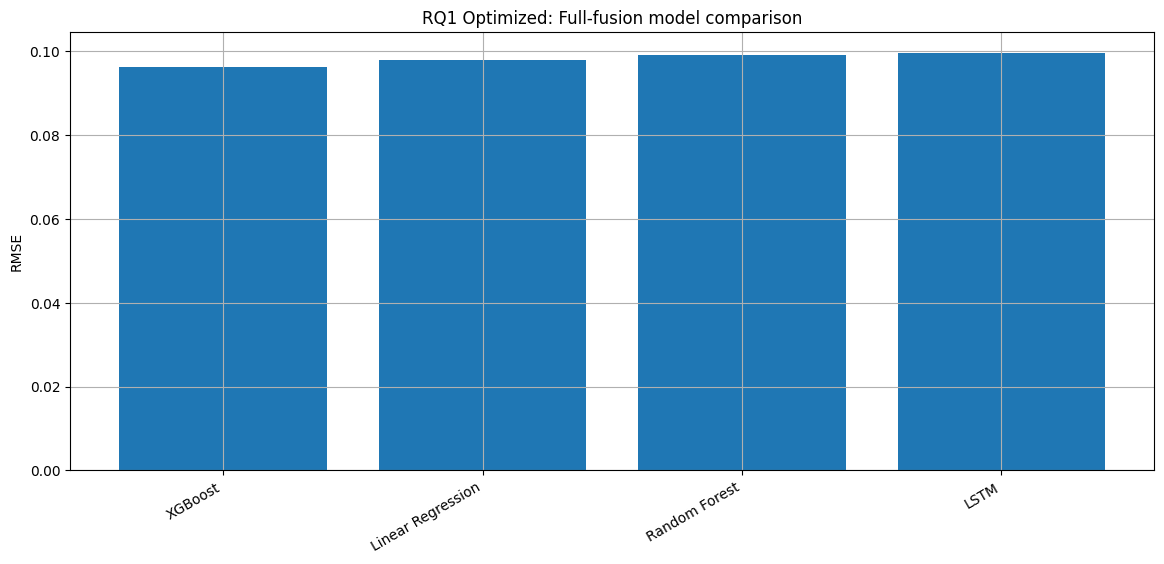

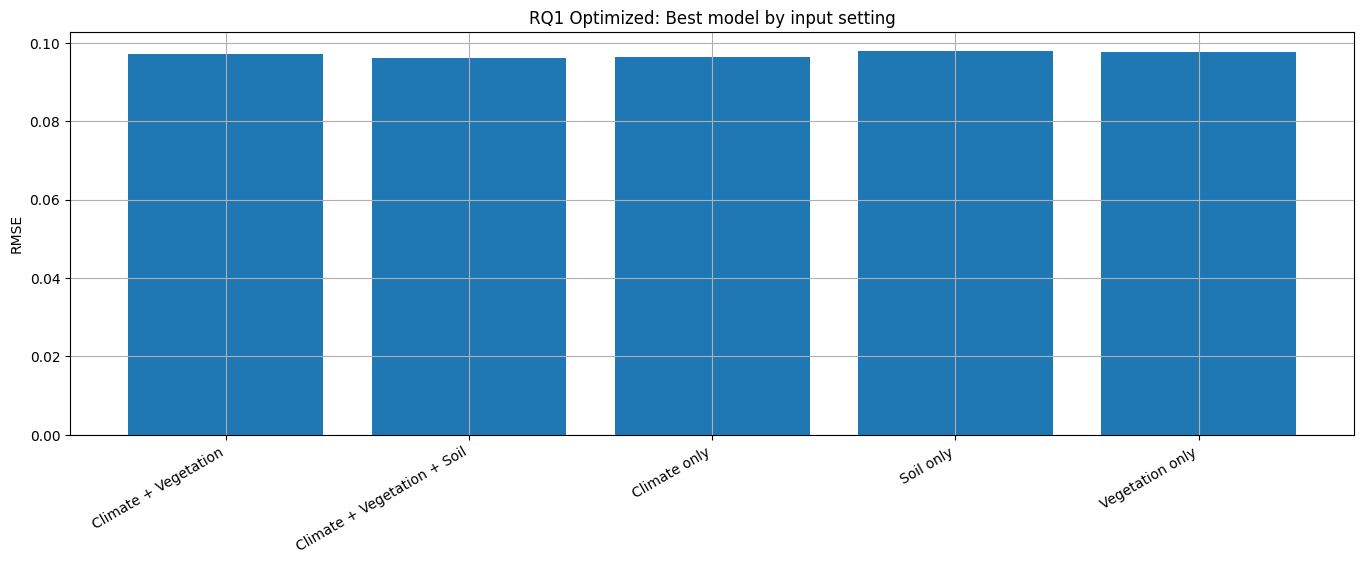

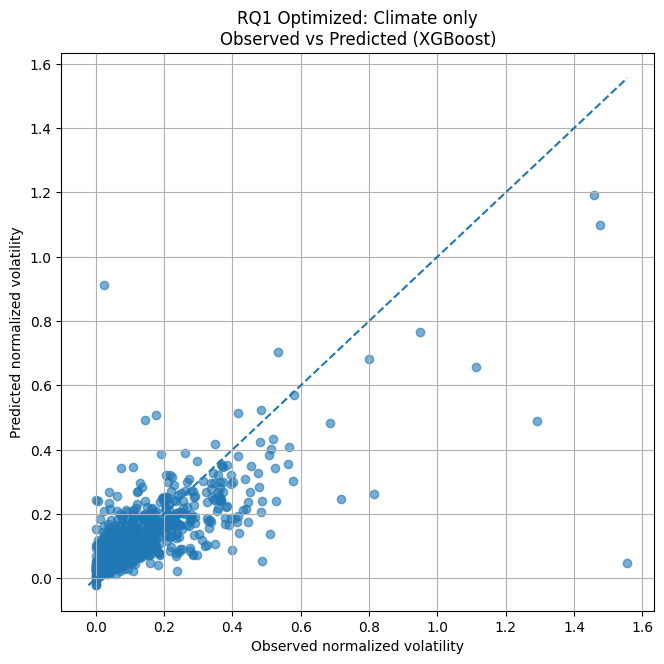

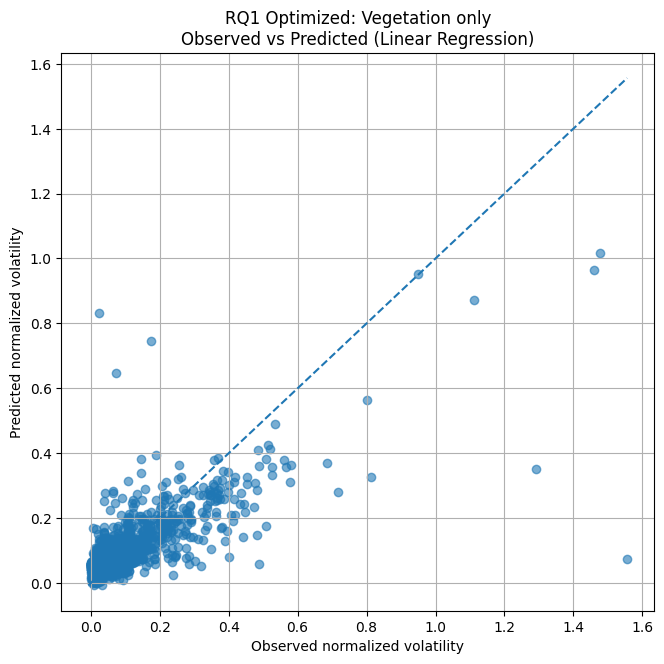

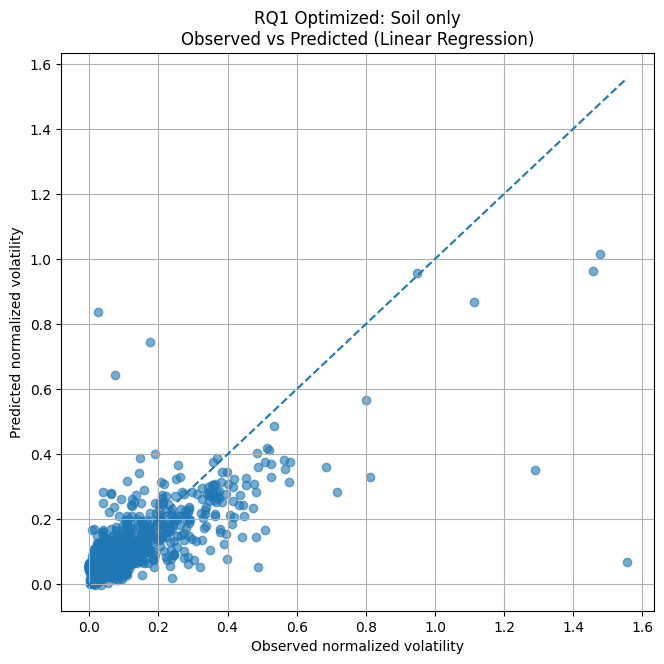

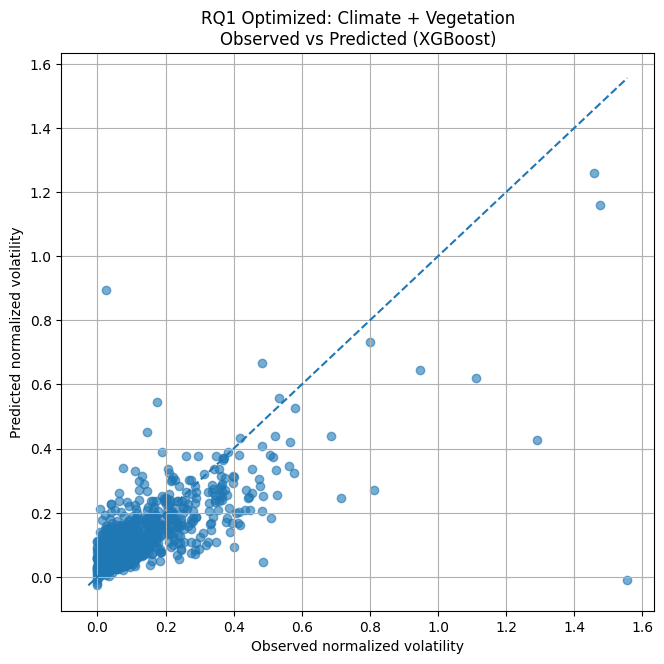

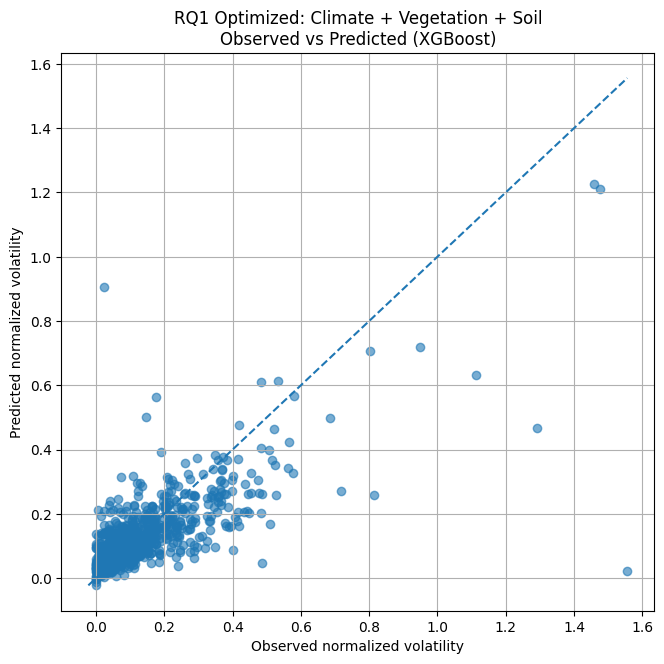

RQ1 optimized completed.
Outputs saved to: /kaggle/working/outputs/RQ1_optimized


In [5]:
# ============================================================
# RQ1 OPTIMIZED — Multi-source model comparison
# Models: Linear Regression, Random Forest, XGBoost, LSTM
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Output folder
# -----------------------------
RQ1_OUT = Path("/kaggle/working/outputs/RQ1_optimized")
RQ1_OUT.mkdir(parents=True, exist_ok=True)

# ============================================================
# Safe plot saving — prevents cropped labels/titles
# ============================================================
def save_plot(base_path):
    fig = plt.gcf()

    fig.tight_layout(pad=2.0)

    fig.savefig(
        f"{base_path}.pdf",
        bbox_inches="tight",
        pad_inches=0.3
    )

    fig.savefig(
        f"{base_path}.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.3
    )

# -----------------------------
# Safety: load df if not already in memory
# -----------------------------
try:
    df
except NameError:
    df = pd.read_csv("/kaggle/working/final_europe_crop_dataset.csv")

df_rq1 = df.copy()

# -----------------------------
# RMSE helper
# -----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# -----------------------------
# Optimized target construction
# -----------------------------
df_rq1 = df_rq1.sort_values(["Country", "crop", "year"]).copy()

df_rq1["log_yield"] = np.log1p(df_rq1["yield"])

df_rq1["log_yield_trend"] = (
    df_rq1.groupby(["Country", "crop"])["log_yield"]
    .transform(lambda x: x.rolling(5, min_periods=2).mean())
)

df_rq1["log_yield_trend"] = df_rq1["log_yield_trend"].fillna(
    df_rq1.groupby(["Country", "crop"])["log_yield"].transform("mean")
)

df_rq1["yield_anomaly_pct"] = (
    df_rq1["log_yield"] - df_rq1["log_yield_trend"]
)

df_rq1["volatility_target_opt"] = (
    df_rq1.groupby(["Country", "crop"])["yield_anomaly_pct"]
    .transform(lambda x: x.rolling(3, min_periods=2).std())
)

df_rq1["volatility_target_opt"] = (
    df_rq1["volatility_target_opt"]
    .fillna(df_rq1["yield_anomaly_pct"].abs())
)

# Remove extreme volatility outliers
low, high = df_rq1["volatility_target_opt"].quantile([0.01, 0.99])

df_rq1 = df_rq1[
    (df_rq1["volatility_target_opt"] >= low) &
    (df_rq1["volatility_target_opt"] <= high)
].copy()

# -----------------------------
# Lag features
# -----------------------------
lag_cols = [
    "temp_mean",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "soil_proxy",
    "veg_index"
]

for col in lag_cols:
    df_rq1[f"{col}_lag1"] = (
        df_rq1.groupby(["Country", "crop"])[col].shift(1)
    )

df_rq1["yield_anomaly_lag1"] = (
    df_rq1.groupby(["Country", "crop"])["yield_anomaly_pct"].shift(1)
)

df_rq1["volatility_lag1"] = (
    df_rq1.groupby(["Country", "crop"])["volatility_target_opt"].shift(1)
)

df_rq1 = df_rq1.dropna().copy()

# -----------------------------
# Feature sets
# -----------------------------
climate_features = [
    "temp_mean",
    "temp_uncertainty",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "temp_mean_lag1",
    "precip_proxy_lag1",
    "solar_proxy_lag1",
    "vpd_proxy_lag1"
]

vegetation_features = [
    "veg_index",
    "veg_index_lag1"
]

soil_features = [
    "soil_proxy",
    "soil_proxy_lag1"
]

history_features = [
    "yield_anomaly_lag1",
    "volatility_lag1"
]

categorical_features = [
    "Country",
    "crop"
]

feature_sets = {
    "Climate only": climate_features + history_features + categorical_features,
    "Vegetation only": vegetation_features + history_features + categorical_features,
    "Soil only": soil_features + history_features + categorical_features,
    "Climate + Vegetation": climate_features + vegetation_features + history_features + categorical_features,
    "Climate + Vegetation + Soil": climate_features + vegetation_features + soil_features + history_features + categorical_features
}

target = "volatility_target_opt"

# -----------------------------
# Safe time-aware split
# -----------------------------
available_years = sorted(df_rq1["year"].dropna().unique())

print("Available years:", available_years[0], "to", available_years[-1])
print("Number of rows before split:", df_rq1.shape)

split_year = int(np.quantile(available_years, 0.75))

train = df_rq1[df_rq1["year"] <= split_year].copy()
test = df_rq1[df_rq1["year"] > split_year].copy()

if len(test) == 0:
    split_year = available_years[-3]
    train = df_rq1[df_rq1["year"] <= split_year].copy()
    test = df_rq1[df_rq1["year"] > split_year].copy()

print("Split year:", split_year)
print("Train rows:", train.shape)
print("Test rows:", test.shape)

if len(train) == 0 or len(test) == 0:
    raise ValueError(
        "Train or test set is empty. Check available years and data filtering."
    )

results = []
predictions_store = {}

# -----------------------------
# Preprocessor
# -----------------------------
def build_preprocessor(num_features):
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

def evaluate(input_setting, model_name, y_true, y_pred):
    return {
        "Input Setting": input_setting,
        "Model": model_name,
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# -----------------------------
# Model loop
# -----------------------------
for input_name, features in feature_sets.items():

    print(f"\nRunning RQ1 input setting: {input_name}")

    num_features = [
        f for f in features
        if f not in categorical_features
    ]

    X_train = train[features]
    X_test = test[features]

    y_train = train[target]
    y_test = test[target]

    preprocessor = build_preprocessor(num_features)

    # 1. Linear Regression as Ridge
    ridge = Pipeline([
        ("prep", preprocessor),
        ("model", Ridge(alpha=1.0))
    ])

    ridge.fit(X_train, y_train)
    pred_ridge = ridge.predict(X_test)

    results.append(
        evaluate(input_name, "Linear Regression", y_test, pred_ridge)
    )

    # 2. Random Forest
    rf = Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=600,
            max_depth=12,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ])

    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    results.append(
        evaluate(input_name, "Random Forest", y_test, pred_rf)
    )

    # 3. XGBoost
    xgb = Pipeline([
        ("prep", preprocessor),
        ("model", XGBRegressor(
            n_estimators=700,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            random_state=42
        ))
    ])

    xgb.fit(X_train, y_train)
    pred_xgb = xgb.predict(X_test)

    results.append(
        evaluate(input_name, "XGBoost", y_test, pred_xgb)
    )

    # 4. LSTM
    lstm_preprocessor = build_preprocessor(num_features)

    X_train_enc = lstm_preprocessor.fit_transform(X_train)
    X_test_enc = lstm_preprocessor.transform(X_test)

    if hasattr(X_train_enc, "toarray"):
        X_train_enc = X_train_enc.toarray()
        X_test_enc = X_test_enc.toarray()

    X_train_lstm = X_train_enc.reshape(
        X_train_enc.shape[0],
        1,
        X_train_enc.shape[1]
    )

    X_test_lstm = X_test_enc.reshape(
        X_test_enc.shape[0],
        1,
        X_test_enc.shape[1]
    )

    tf.random.set_seed(42)

    lstm = Sequential([
        LSTM(64, input_shape=(1, X_train_lstm.shape[2])),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    lstm.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    lstm.fit(
        X_train_lstm,
        y_train,
        validation_split=0.2,
        epochs=80,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )

    pred_lstm = lstm.predict(
        X_test_lstm,
        verbose=0
    ).flatten()

    results.append(
        evaluate(input_name, "LSTM", y_test, pred_lstm)
    )

    preds = {
        "Linear Regression": pred_ridge,
        "Random Forest": pred_rf,
        "XGBoost": pred_xgb,
        "LSTM": pred_lstm
    }

    best_model = min(
        preds.keys(),
        key=lambda m: rmse(y_test, preds[m])
    )

    predictions_store[input_name] = {
        "y_test": y_test.values,
        "pred": preds[best_model],
        "best_model": best_model
    }

# -----------------------------
# Results table
# -----------------------------
rq1_results = pd.DataFrame(results)

rq1_results = rq1_results.sort_values(
    ["Input Setting", "RMSE"]
).reset_index(drop=True)

display(rq1_results)

rq1_results.to_csv(
    RQ1_OUT / "table_rq1_optimized_all_models.csv",
    index=False
)

# -----------------------------
# Best model per input setting
# -----------------------------
best_by_input = (
    rq1_results.sort_values("RMSE")
    .groupby("Input Setting", as_index=False)
    .first()
)

display(best_by_input)

best_by_input.to_csv(
    RQ1_OUT / "table_rq1_best_model_by_input_setting.csv",
    index=False
)

# -----------------------------
# Graph 1: Full-fusion model comparison
# -----------------------------
fusion_df = rq1_results[
    rq1_results["Input Setting"] == "Climate + Vegetation + Soil"
].copy()

plt.figure(figsize=(12, 6))

plt.bar(
    fusion_df["Model"],
    fusion_df["RMSE"]
)

plt.ylabel("RMSE")
plt.title("RQ1 Optimized: Full-fusion model comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(True)

save_plot(
    RQ1_OUT / "figure_rq1_full_fusion_model_comparison"
)

plt.show()

# -----------------------------
# Graph 2: Best input-setting comparison
# -----------------------------
plt.figure(figsize=(14, 6))

plt.bar(
    best_by_input["Input Setting"],
    best_by_input["RMSE"]
)

plt.ylabel("RMSE")
plt.title("RQ1 Optimized: Best model by input setting")
plt.xticks(rotation=30, ha="right")
plt.grid(True)

save_plot(
    RQ1_OUT / "figure_rq1_best_input_setting_comparison"
)

plt.show()

# -----------------------------
# Graph 3: Observed vs predicted per input setting
# -----------------------------
for input_name, obj in predictions_store.items():

    y_test = obj["y_test"]
    pred = obj["pred"]
    best_model = obj["best_model"]

    plt.figure(figsize=(7, 7))

    plt.scatter(
        y_test,
        pred,
        alpha=0.6
    )

    lim_min = min(
        y_test.min(),
        pred.min()
    )

    lim_max = max(
        y_test.max(),
        pred.max()
    )

    plt.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        linestyle="--"
    )

    plt.xlabel("Observed normalized volatility")
    plt.ylabel("Predicted normalized volatility")

    plt.title(
        f"RQ1 Optimized: {input_name}\nObserved vs Predicted ({best_model})"
    )

    plt.grid(True)

    safe_name = (
        input_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_plot(
        RQ1_OUT / f"figure_rq1_{safe_name}_observed_vs_predicted"
    )

    plt.show()

print("RQ1 optimized completed.")
print("Outputs saved to:", RQ1_OUT)

## RQ2: Uncertainty-aware forecasting with all four model types

RQ2 split year: 2000
Train: (2672, 29) Test: (1109, 29)


,Model,RMSE,MAE,R2,Coverage_90,Mean_Interval_Width
0,XGBoost,0.098420,0.053400,0.536728,0.823264,0.161672
1,LSTM,0.099962,0.054129,0.522094,0.934175,0.314292
2,Random Forest,0.100004,0.053224,0.521688,0.807033,0.163865
3,Linear Regression,0.100028,0.053922,0.521460,0.941389,0.333803
4,Random Forest Ensemble,0.100247,0.053077,0.519361,0.293959,0.048503


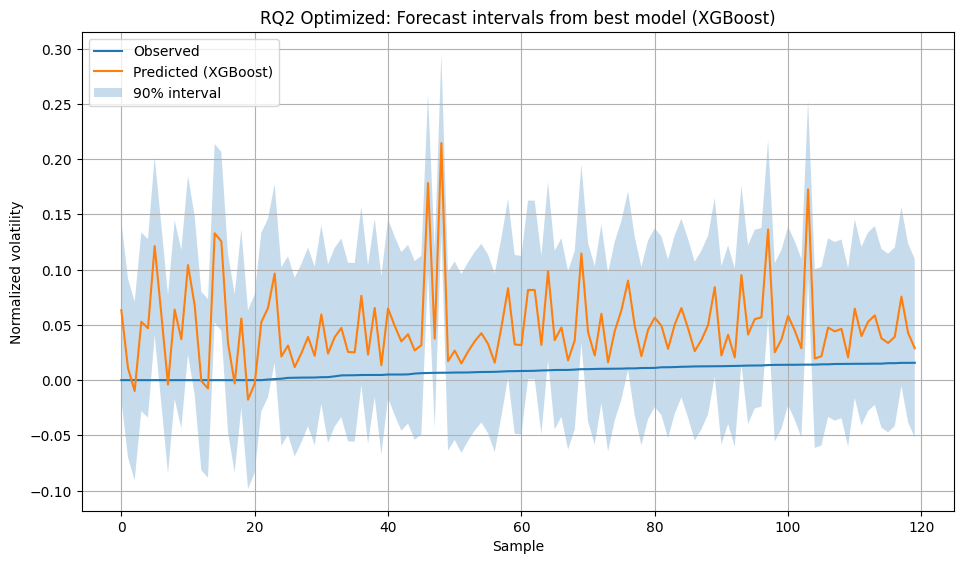

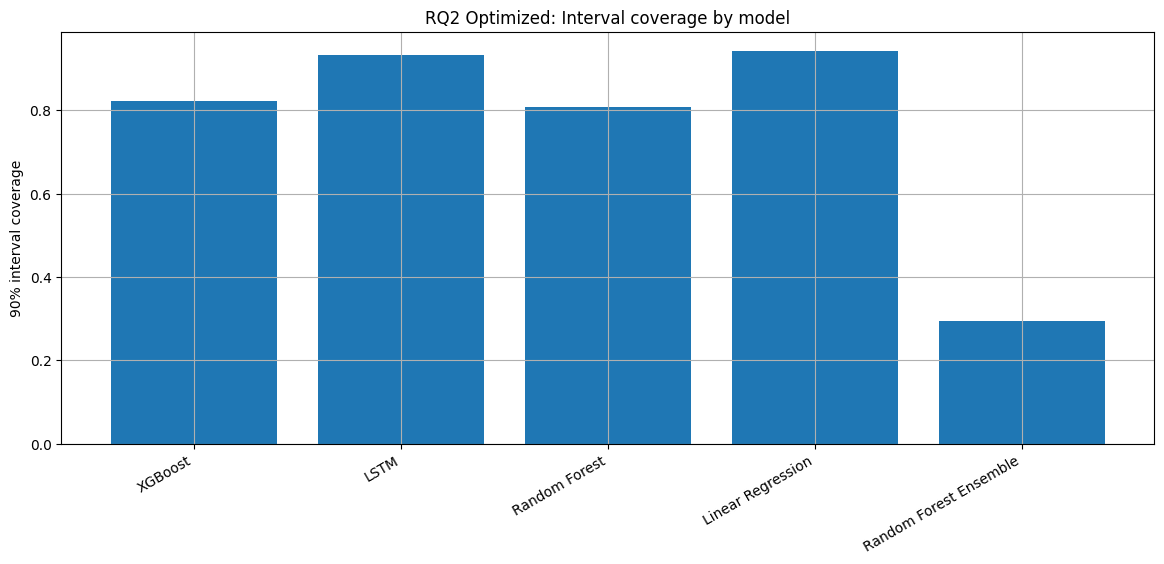

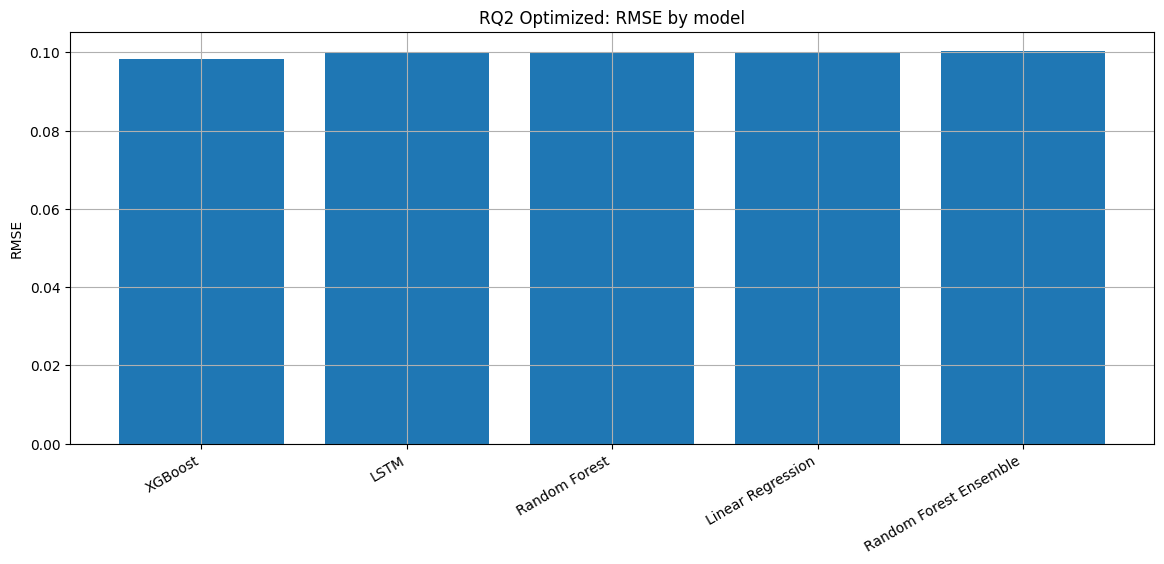

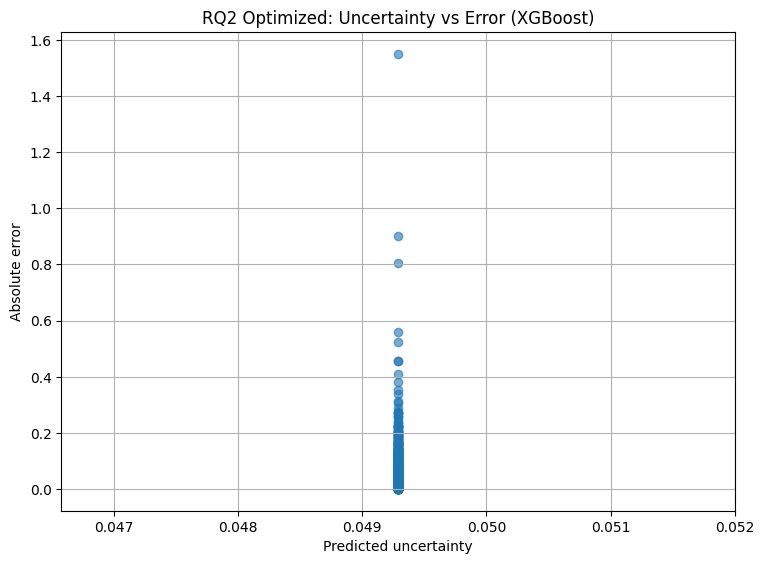

RQ2 optimized all-model uncertainty forecasting completed.
Outputs saved to: /kaggle/working/outputs/RQ2_optimized_all_models


In [6]:
# ============================================================
# RQ2 OPTIMIZED — Uncertainty-aware forecasting with all models
# Models: Linear Regression, Random Forest, XGBoost, LSTM, RF Ensemble
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RQ2_OUT = Path("/kaggle/working/outputs/RQ2_optimized_all_models")
RQ2_OUT.mkdir(parents=True, exist_ok=True)

# ============================================================
# Safe plot saving — prevents cropped labels/titles
# ============================================================
def save_plot(base_path):
    fig = plt.gcf()

    fig.tight_layout(pad=2.0)

    fig.savefig(
        f"{base_path}.pdf",
        bbox_inches="tight",
        pad_inches=0.3
    )

    fig.savefig(
        f"{base_path}.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.3
    )

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ------------------------------------------------------------
# Use optimized RQ1 dataframe if available
# ------------------------------------------------------------
try:
    df_rq2 = df_rq1.copy()
except NameError:
    df_rq2 = df.copy()

# ------------------------------------------------------------
# Ensure optimized target exists
# ------------------------------------------------------------
if "volatility_target_opt" not in df_rq2.columns:

    df_rq2 = df_rq2.sort_values(
        ["Country", "crop", "year"]
    ).copy()

    df_rq2["log_yield"] = np.log1p(df_rq2["yield"])

    df_rq2["log_yield_trend"] = (
        df_rq2.groupby(["Country", "crop"])["log_yield"]
        .transform(lambda x: x.rolling(5, min_periods=2).mean())
    )

    df_rq2["log_yield_trend"] = (
        df_rq2["log_yield_trend"]
        .fillna(
            df_rq2.groupby(["Country", "crop"])["log_yield"]
            .transform("mean")
        )
    )

    df_rq2["yield_anomaly_pct"] = (
        df_rq2["log_yield"]
        - df_rq2["log_yield_trend"]
    )

    df_rq2["volatility_target_opt"] = (
        df_rq2.groupby(["Country", "crop"])["yield_anomaly_pct"]
        .transform(lambda x: x.rolling(3, min_periods=2).std())
    )

    df_rq2["volatility_target_opt"] = (
        df_rq2["volatility_target_opt"]
        .fillna(df_rq2["yield_anomaly_pct"].abs())
    )

# ------------------------------------------------------------
# Ensure lag features exist
# ------------------------------------------------------------
for col in [
    "temp_mean",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "soil_proxy",
    "veg_index"
]:
    lag_col = f"{col}_lag1"

    if lag_col not in df_rq2.columns:
        df_rq2[lag_col] = (
            df_rq2.groupby(["Country", "crop"])[col]
            .shift(1)
        )

if "yield_anomaly_lag1" not in df_rq2.columns:
    df_rq2["yield_anomaly_lag1"] = (
        df_rq2.groupby(["Country", "crop"])["yield_anomaly_pct"]
        .shift(1)
    )

if "volatility_lag1" not in df_rq2.columns:
    df_rq2["volatility_lag1"] = (
        df_rq2.groupby(["Country", "crop"])["volatility_target_opt"]
        .shift(1)
    )

# ------------------------------------------------------------
# Features and target
# ------------------------------------------------------------
features = [
    "temp_mean",
    "temp_uncertainty",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "soil_proxy",
    "veg_index",
    "temp_mean_lag1",
    "precip_proxy_lag1",
    "solar_proxy_lag1",
    "vpd_proxy_lag1",
    "soil_proxy_lag1",
    "veg_index_lag1",
    "yield_anomaly_lag1",
    "volatility_lag1"
]

target = "volatility_target_opt"

df_rq2 = df_rq2.dropna(
    subset=features + [target]
).copy()

# ------------------------------------------------------------
# Safe time split
# ------------------------------------------------------------
available_years = sorted(
    df_rq2["year"].dropna().unique()
)

split_year = int(
    np.quantile(available_years, 0.75)
)

train = df_rq2[
    df_rq2["year"] <= split_year
].copy()

test = df_rq2[
    df_rq2["year"] > split_year
].copy()

if len(test) == 0:
    split_year = available_years[-3]

    train = df_rq2[
        df_rq2["year"] <= split_year
    ].copy()

    test = df_rq2[
        df_rq2["year"] > split_year
    ].copy()

print("RQ2 split year:", split_year)
print("Train:", train.shape, "Test:", test.shape)

X_train = train[features]
X_test = test[features]

y_train = train[target].values
y_test = test[target].values

# ------------------------------------------------------------
# Scale for Ridge and LSTM
# ------------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []
pred_store = {}

def interval_metrics(y_true, pred_mean, pred_std):

    pred_std = np.maximum(pred_std, 1e-6)

    lower = pred_mean - 1.64 * pred_std
    upper = pred_mean + 1.64 * pred_std

    coverage = np.mean(
        (y_true >= lower) &
        (y_true <= upper)
    )

    width = np.mean(upper - lower)

    return lower, upper, coverage, width

# ------------------------------------------------------------
# 1. Linear Regression / Ridge
# ------------------------------------------------------------
ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train_scaled,
    y_train
)

pred_ridge = ridge.predict(X_test_scaled)

train_resid = (
    y_train -
    ridge.predict(X_train_scaled)
)

ridge_std = np.repeat(
    np.std(train_resid),
    len(y_test)
)

ridge_lower, ridge_upper, ridge_cov, ridge_width = (
    interval_metrics(
        y_test,
        pred_ridge,
        ridge_std
    )
)

results.append({
    "Model": "Linear Regression",
    "RMSE": rmse(y_test, pred_ridge),
    "MAE": mean_absolute_error(y_test, pred_ridge),
    "R2": r2_score(y_test, pred_ridge),
    "Coverage_90": ridge_cov,
    "Mean_Interval_Width": ridge_width
})

pred_store["Linear Regression"] = {
    "pred": pred_ridge,
    "std": ridge_std,
    "lower": ridge_lower,
    "upper": ridge_upper
}

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

tree_preds = np.array([
    tree.predict(X_test)
    for tree in rf.estimators_
])

rf_std = tree_preds.std(axis=0)

rf_lower, rf_upper, rf_cov, rf_width = (
    interval_metrics(
        y_test,
        pred_rf,
        rf_std
    )
)

results.append({
    "Model": "Random Forest",
    "RMSE": rmse(y_test, pred_rf),
    "MAE": mean_absolute_error(y_test, pred_rf),
    "R2": r2_score(y_test, pred_rf),
    "Coverage_90": rf_cov,
    "Mean_Interval_Width": rf_width
})

pred_store["Random Forest"] = {
    "pred": pred_rf,
    "std": rf_std,
    "lower": rf_lower,
    "upper": rf_upper
}

# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------
xgb = XGBRegressor(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

xgb_train_resid = (
    y_train -
    xgb.predict(X_train)
)

xgb_std = np.repeat(
    np.std(xgb_train_resid),
    len(y_test)
)

xgb_lower, xgb_upper, xgb_cov, xgb_width = (
    interval_metrics(
        y_test,
        pred_xgb,
        xgb_std
    )
)

results.append({
    "Model": "XGBoost",
    "RMSE": rmse(y_test, pred_xgb),
    "MAE": mean_absolute_error(y_test, pred_xgb),
    "R2": r2_score(y_test, pred_xgb),
    "Coverage_90": xgb_cov,
    "Mean_Interval_Width": xgb_width
})

pred_store["XGBoost"] = {
    "pred": pred_xgb,
    "std": xgb_std,
    "lower": xgb_lower,
    "upper": xgb_upper
}

# ------------------------------------------------------------
# LSTM
# ------------------------------------------------------------
X_train_lstm = X_train_scaled.reshape(
    X_train_scaled.shape[0], 1, X_train_scaled.shape[1]
)

X_test_lstm = X_test_scaled.reshape(
    X_test_scaled.shape[0], 1, X_test_scaled.shape[1]
)

tf.random.set_seed(42)

lstm = Sequential([
    LSTM(64, input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

lstm.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)

pred_lstm = lstm.predict(
    X_test_lstm,
    verbose=0
).flatten()

lstm_train_pred = lstm.predict(
    X_train_lstm,
    verbose=0
).flatten()

lstm_std = np.repeat(
    np.std(y_train - lstm_train_pred),
    len(y_test)
)

lstm_lower, lstm_upper, lstm_cov, lstm_width = (
    interval_metrics(
        y_test,
        pred_lstm,
        lstm_std
    )
)

results.append({
    "Model": "LSTM",
    "RMSE": rmse(y_test, pred_lstm),
    "MAE": mean_absolute_error(y_test, pred_lstm),
    "R2": r2_score(y_test, pred_lstm),
    "Coverage_90": lstm_cov,
    "Mean_Interval_Width": lstm_width
})

pred_store["LSTM"] = {
    "pred": pred_lstm,
    "std": lstm_std,
    "lower": lstm_lower,
    "upper": lstm_upper
}

# ------------------------------------------------------------
# Random Forest Ensemble
# ------------------------------------------------------------
ensemble_preds = []

for seed in range(20):

    m = RandomForestRegressor(
        n_estimators=350,
        max_depth=12,
        min_samples_leaf=3,
        random_state=seed,
        n_jobs=-1
    )

    boot_idx = np.random.RandomState(seed).choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    m.fit(
        X_train.iloc[boot_idx],
        y_train[boot_idx]
    )

    ensemble_preds.append(
        m.predict(X_test)
    )

ensemble_preds = np.array(ensemble_preds)

pred_ens = ensemble_preds.mean(axis=0)
ens_std = ensemble_preds.std(axis=0)

ens_lower, ens_upper, ens_cov, ens_width = (
    interval_metrics(
        y_test,
        pred_ens,
        ens_std
    )
)

results.append({
    "Model": "Random Forest Ensemble",
    "RMSE": rmse(y_test, pred_ens),
    "MAE": mean_absolute_error(y_test, pred_ens),
    "R2": r2_score(y_test, pred_ens),
    "Coverage_90": ens_cov,
    "Mean_Interval_Width": ens_width
})

pred_store["Random Forest Ensemble"] = {
    "pred": pred_ens,
    "std": ens_std,
    "lower": ens_lower,
    "upper": ens_upper
}

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
rq2_results = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(rq2_results)

rq2_results.to_csv(
    RQ2_OUT / "table_rq2_optimized_all_models_uncertainty.csv",
    index=False
)

# ------------------------------------------------------------
# Best model forecast intervals
# ------------------------------------------------------------
best_model = rq2_results.iloc[0]["Model"]
best = pred_store[best_model]

order = np.argsort(y_test)[:120]

plt.figure(figsize=(10, 6))

plt.plot(
    y_test[order],
    label="Observed"
)

plt.plot(
    best["pred"][order],
    label=f"Predicted ({best_model})"
)

plt.fill_between(
    range(len(order)),
    best["lower"][order],
    best["upper"][order],
    alpha=0.25,
    label="90% interval"
)

plt.title(
    f"RQ2 Optimized: Forecast intervals from best model ({best_model})"
)

plt.xlabel("Sample")
plt.ylabel("Normalized volatility")
plt.legend()
plt.grid(True)

save_plot(
    RQ2_OUT / "figure_rq2_best_model_forecast_intervals"
)

plt.show()

# ------------------------------------------------------------
# Coverage comparison
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.bar(
    rq2_results["Model"],
    rq2_results["Coverage_90"]
)

plt.ylabel("90% interval coverage")
plt.title("RQ2 Optimized: Interval coverage by model")
plt.xticks(rotation=30, ha="right")
plt.grid(True)

save_plot(
    RQ2_OUT / "figure_rq2_coverage_by_model"
)

plt.show()

# ------------------------------------------------------------
# RMSE comparison
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.bar(
    rq2_results["Model"],
    rq2_results["RMSE"]
)

plt.ylabel("RMSE")
plt.title("RQ2 Optimized: RMSE by model")
plt.xticks(rotation=30, ha="right")
plt.grid(True)

save_plot(
    RQ2_OUT / "figure_rq2_rmse_by_model"
)

plt.show()

# ------------------------------------------------------------
# Uncertainty vs error
# ------------------------------------------------------------
errors = np.abs(
    y_test - best["pred"]
)

plt.figure(figsize=(8, 6))

plt.scatter(
    best["std"],
    errors,
    alpha=0.6
)

plt.xlabel("Predicted uncertainty")
plt.ylabel("Absolute error")

plt.title(
    f"RQ2 Optimized: Uncertainty vs Error ({best_model})"
)

plt.grid(True)

save_plot(
    RQ2_OUT / "figure_rq2_uncertainty_vs_error"
)

plt.show()

print("RQ2 optimized all-model uncertainty forecasting completed.")
print("Outputs saved to:", RQ2_OUT)

## RQ3: Spatial spillover modeling with all four model types

RQ3 split: 2000
Train: (2651, 41) Test: (1109, 41)


,Feature Set,Model,RMSE,MAE,R2
0,Non-spatial,XGBoost,0.097587,0.052760,0.544535
1,Non-spatial,Linear Regression,0.099915,0.053701,0.522547
2,Non-spatial,Random Forest,0.100190,0.052747,0.519913
3,Non-spatial,LSTM,0.100900,0.053131,0.513086
4,Spatial-spillover,XGBoost,0.098373,0.054015,0.537164
5,Spatial-spillover,Random Forest,0.099472,0.052139,0.526772
6,Spatial-spillover,Linear Regression,0.099784,0.053852,0.523791
7,Spatial-spillover,LSTM,0.107600,0.059224,0.446273


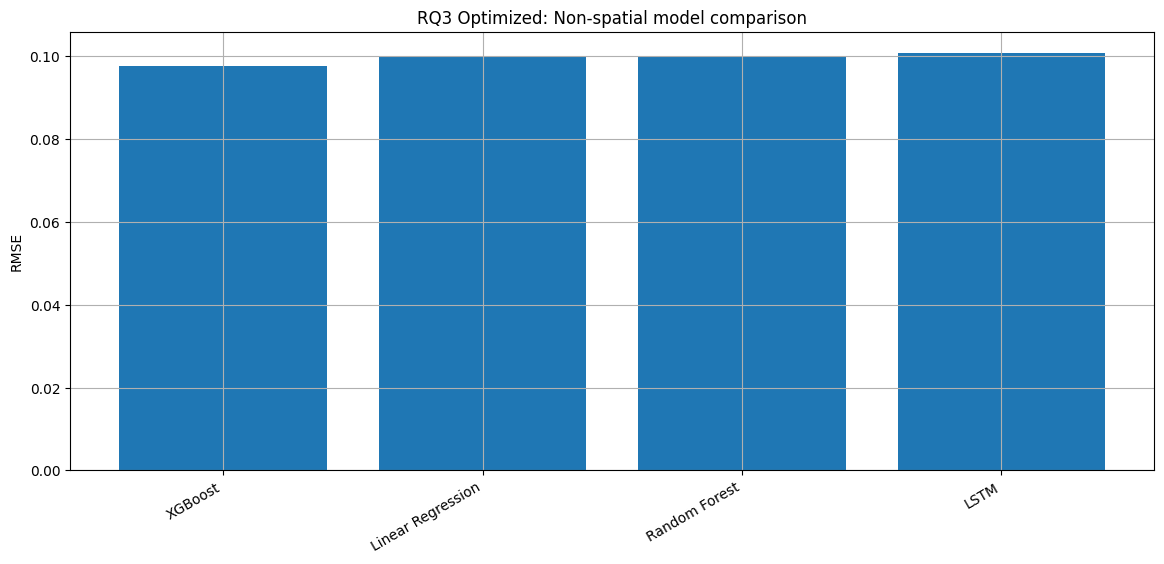

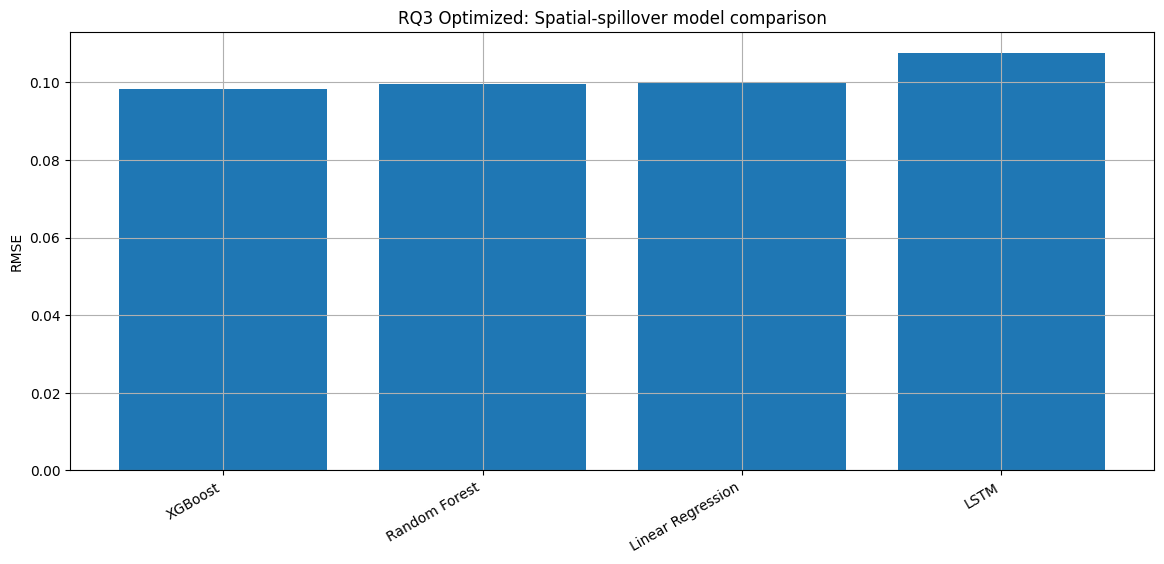

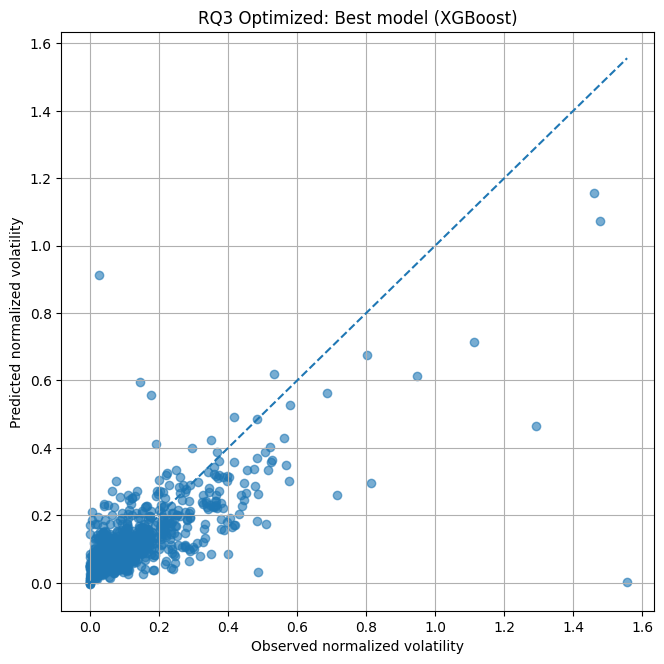

RQ3 optimized completed.
Outputs: /kaggle/working/outputs/RQ3_optimized


In [7]:
# ============================================================
# RQ3 OPTIMIZED — Spatial spillover modeling (ALL MODELS)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RQ3_OUT = Path("/kaggle/working/outputs/RQ3_optimized")
RQ3_OUT.mkdir(parents=True, exist_ok=True)

# ============================================================
# Safe plot saving — prevents cropped labels/titles
# ============================================================
def save_plot(base_path):
    fig = plt.gcf()
    fig.tight_layout(pad=2.0)

    fig.savefig(
        f"{base_path}.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.3
    )

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# ------------------------------------------------------------
# Use optimized dataset
# ------------------------------------------------------------
df_rq3 = df_rq1.copy()

target = "volatility_target_opt"

# ------------------------------------------------------------
# SPATIAL FEATURES (IMPROVED)
# ------------------------------------------------------------
base_cols = [
    "temp_mean",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "soil_proxy",
    "veg_index"
]

# Leave-one-out regional mean
for col in base_cols:
    df_rq3[f"spatial_mean_{col}"] = (
        df_rq3.groupby(["crop", "year"])[col]
        .transform(lambda x: (x.sum() - x) / max(len(x) - 1, 1))
    )

# Spatial variability
for col in base_cols:
    df_rq3[f"spatial_std_{col}"] = (
        df_rq3.groupby(["crop", "year"])[col]
        .transform("std")
    )

df_rq3 = df_rq3.dropna()

# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------
non_spatial_features = [
    "temp_mean",
    "temp_uncertainty",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "soil_proxy",
    "veg_index",
    "yield_anomaly_lag1",
    "volatility_lag1"
]

spatial_features = (
    non_spatial_features
    + [f"spatial_mean_{c}" for c in base_cols]
    + [f"spatial_std_{c}" for c in base_cols]
)

# ------------------------------------------------------------
# SAFE SPLIT
# ------------------------------------------------------------
years = sorted(df_rq3["year"].unique())
split_year = int(np.quantile(years, 0.75))

train = df_rq3[df_rq3["year"] <= split_year]
test = df_rq3[df_rq3["year"] > split_year]

if len(test) == 0:
    split_year = years[-3]
    train = df_rq3[df_rq3["year"] <= split_year]
    test = df_rq3[df_rq3["year"] > split_year]

print("RQ3 split:", split_year)
print("Train:", train.shape, "Test:", test.shape)

results = []

# ------------------------------------------------------------
# MODEL FUNCTION
# ------------------------------------------------------------
def run_models(X_train, X_test, y_train, y_test, label):

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Linear Regression
    lr = Ridge(alpha=1.0)
    lr.fit(X_train_s, y_train)
    pred_lr = lr.predict(X_test_s)

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=600,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    # XGBoost
    xgb = XGBRegressor(
        n_estimators=700,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=42
    )

    xgb.fit(X_train, y_train)
    pred_xgb = xgb.predict(X_test)

    # LSTM
    X_train_lstm = X_train_s.reshape(
        X_train_s.shape[0],
        1,
        X_train_s.shape[1]
    )

    X_test_lstm = X_test_s.reshape(
        X_test_s.shape[0],
        1,
        X_test_s.shape[1]
    )

    tf.random.set_seed(42)

    lstm = Sequential([
        LSTM(64, input_shape=(1, X_train_lstm.shape[2])),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    lstm.compile(
        optimizer="adam",
        loss="mse"
    )

    lstm.fit(
        X_train_lstm,
        y_train,
        validation_split=0.2,
        epochs=60,
        batch_size=32,
        verbose=0,
        callbacks=[EarlyStopping(patience=6, restore_best_weights=True)]
    )

    pred_lstm = lstm.predict(
        X_test_lstm,
        verbose=0
    ).flatten()

    preds = {
        "Linear Regression": pred_lr,
        "Random Forest": pred_rf,
        "XGBoost": pred_xgb,
        "LSTM": pred_lstm
    }

    for m, p in preds.items():
        results.append({
            "Feature Set": label,
            "Model": m,
            "RMSE": rmse(y_test, p),
            "MAE": mean_absolute_error(y_test, p),
            "R2": r2_score(y_test, p)
        })

    return preds

# ------------------------------------------------------------
# RUN BOTH SETTINGS
# ------------------------------------------------------------
y_train = train[target].values
y_test = test[target].values

preds_non = run_models(
    train[non_spatial_features],
    test[non_spatial_features],
    y_train,
    y_test,
    "Non-spatial"
)

preds_sp = run_models(
    train[spatial_features],
    test[spatial_features],
    y_train,
    y_test,
    "Spatial-spillover"
)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------
rq3_df = (
    pd.DataFrame(results)
    .sort_values(["Feature Set", "RMSE"])
    .reset_index(drop=True)
)

display(rq3_df)

rq3_df.to_csv(
    RQ3_OUT / "table_rq3_optimized.csv",
    index=False
)

# ------------------------------------------------------------
# PLOT: MODEL COMPARISON
# ------------------------------------------------------------
for label in ["Non-spatial", "Spatial-spillover"]:
    sub = rq3_df[rq3_df["Feature Set"] == label]

    plt.figure(figsize=(12, 6))

    plt.bar(
        sub["Model"],
        sub["RMSE"]
    )

    plt.title(f"RQ3 Optimized: {label} model comparison")
    plt.ylabel("RMSE")
    plt.xticks(rotation=30, ha="right")
    plt.grid(True)

    save_plot(RQ3_OUT / f"figure_rq3_{label}_comparison")
    plt.show()

# ------------------------------------------------------------
# BEST MODEL PLOT
# ------------------------------------------------------------
best = rq3_df.sort_values("RMSE").iloc[0]

if best["Feature Set"] == "Non-spatial":
    pred = preds_non[best["Model"]]
else:
    pred = preds_sp[best["Model"]]

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    pred,
    alpha=0.6
)

mn = min(y_test.min(), pred.min())
mx = max(y_test.max(), pred.max())

plt.plot(
    [mn, mx],
    [mn, mx],
    linestyle="--"
)

plt.xlabel("Observed normalized volatility")
plt.ylabel("Predicted normalized volatility")
plt.title(f"RQ3 Optimized: Best model ({best['Model']})")
plt.grid(True)

save_plot(RQ3_OUT / "figure_rq3_best_model")
plt.show()

print("RQ3 optimized completed.")
print("Outputs:", RQ3_OUT)

## RQ4: Growth-stage / feature importance with all four model types

RQ4 split year: 2000
Train: (2672, 29) Test: (1109, 29)


,Model,RMSE,MAE,R2
0,XGBoost,0.098420,0.053400,0.536728
1,Random Forest,0.100004,0.053224,0.521688
2,Linear Regression,0.100028,0.053922,0.521460
3,LSTM,0.101470,0.054874,0.507564


,Feature,Linear Regression,Random Forest,XGBoost,LSTM,Mean_Importance
14,volatility_lag1,1.000000,1.000000,1.000000,1.000000,1.000000
13,yield_anomaly_lag1,0.007352,0.098310,0.354112,0.296418,0.189048
7,temp_mean_lag1,0.321991,0.009688,0.087383,0.033059,0.113030
6,veg_index,0.239405,0.020413,0.094632,0.083801,0.109563
3,solar_proxy,0.002554,0.014298,0.115829,0.078040,0.052680
5,soil_proxy,0.028672,0.019348,0.101858,0.057933,0.051953
11,soil_proxy_lag1,0.003826,0.016341,0.123585,0.050418,0.048542
2,precip_proxy,0.063018,0.019114,0.090587,0.019397,0.048029
0,temp_mean,0.031574,0.018124,0.105542,0.024920,0.045040
9,solar_proxy_lag1,0.025346,0.014826,0.084883,0.053030,0.044521


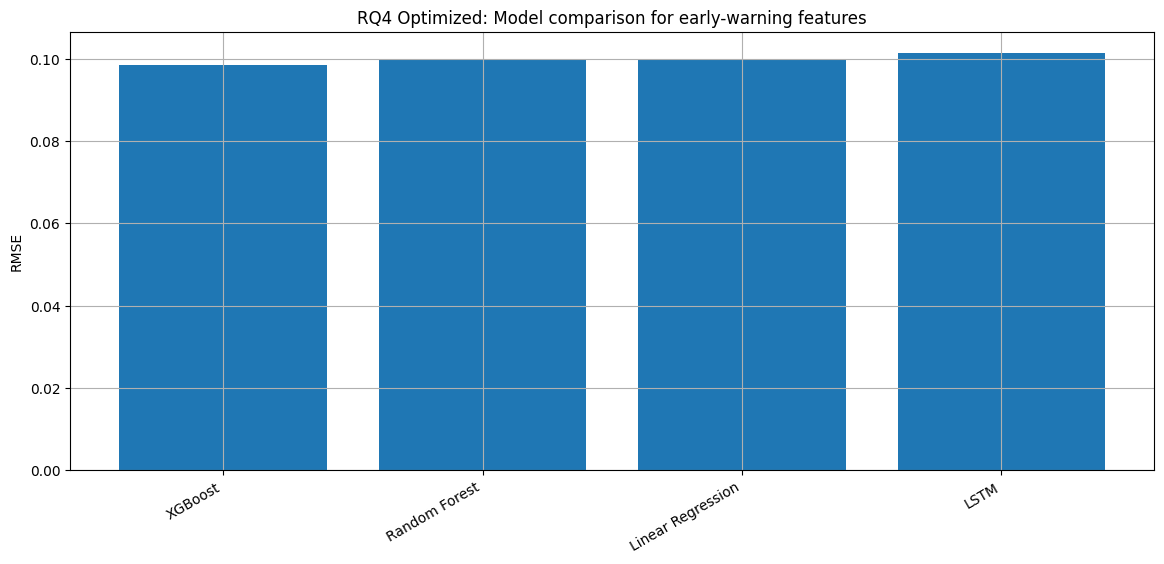

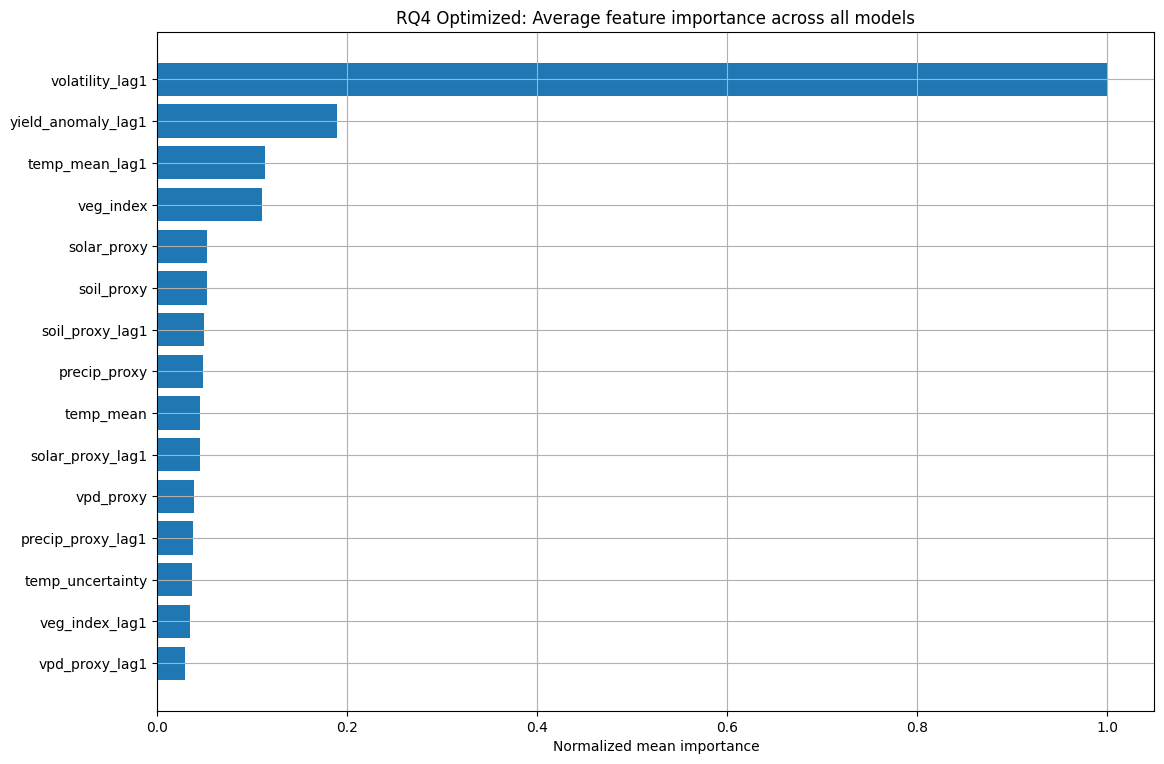

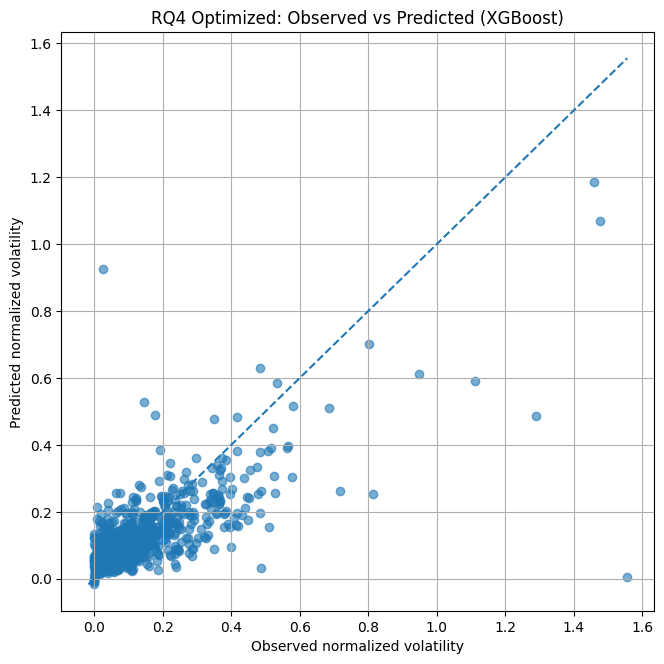

RQ4 optimized completed.
Outputs saved to: /kaggle/working/outputs/RQ4_optimized


In [8]:
# ============================================================
# RQ4 OPTIMIZED — Early-warning feature importance (ALL MODELS)
# Models: Linear Regression, Random Forest, XGBoost, LSTM
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RQ4_OUT = Path("/kaggle/working/outputs/RQ4_optimized")
RQ4_OUT.mkdir(parents=True, exist_ok=True)

# ============================================================
# Safe plot saving — prevents cropped labels/titles
# ============================================================
def save_plot(base_path):
    fig = plt.gcf()
    fig.tight_layout(pad=2.0)

    fig.savefig(
        f"{base_path}.pdf",
        bbox_inches="tight",
        pad_inches=0.3
    )

    fig.savefig(
        f"{base_path}.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.3
    )

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# ------------------------------------------------------------
# Use optimized data from RQ1
# ------------------------------------------------------------
df_rq4 = df_rq1.copy()

target = "volatility_target_opt"

# ------------------------------------------------------------
# Early-warning feature sets
# ------------------------------------------------------------
early_features = [
    "temp_mean",
    "temp_uncertainty",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "soil_proxy",
    "veg_index",
    "temp_mean_lag1",
    "precip_proxy_lag1",
    "solar_proxy_lag1",
    "vpd_proxy_lag1",
    "soil_proxy_lag1",
    "veg_index_lag1",
    "yield_anomaly_lag1",
    "volatility_lag1"
]

df_rq4 = df_rq4.dropna(subset=early_features + [target]).copy()

# ------------------------------------------------------------
# Safe time split
# ------------------------------------------------------------
years = sorted(df_rq4["year"].unique())
split_year = int(np.quantile(years, 0.75))

train = df_rq4[df_rq4["year"] <= split_year].copy()
test = df_rq4[df_rq4["year"] > split_year].copy()

if len(test) == 0:
    split_year = years[-3]
    train = df_rq4[df_rq4["year"] <= split_year].copy()
    test = df_rq4[df_rq4["year"] > split_year].copy()

print("RQ4 split year:", split_year)
print("Train:", train.shape, "Test:", test.shape)

X_train = train[early_features]
X_test = test[early_features]

y_train = train[target].values
y_test = test[target].values

# ------------------------------------------------------------
# Scaling
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

results = []
importance_rows = {}
predictions = {}

# ------------------------------------------------------------
# 1. Linear Regression / Ridge
# ------------------------------------------------------------
lr = Ridge(alpha=1.0)
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)

results.append({
    "Model": "Linear Regression",
    "RMSE": rmse(y_test, pred_lr),
    "MAE": mean_absolute_error(y_test, pred_lr),
    "R2": r2_score(y_test, pred_lr)
})

importance_rows["Linear Regression"] = np.abs(lr.coef_)
predictions["Linear Regression"] = pred_lr

# ------------------------------------------------------------
# 2. Random Forest
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

results.append({
    "Model": "Random Forest",
    "RMSE": rmse(y_test, pred_rf),
    "MAE": mean_absolute_error(y_test, pred_rf),
    "R2": r2_score(y_test, pred_rf)
})

importance_rows["Random Forest"] = rf.feature_importances_
predictions["Random Forest"] = pred_rf

# ------------------------------------------------------------
# 3. XGBoost
# ------------------------------------------------------------
xgb = XGBRegressor(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

results.append({
    "Model": "XGBoost",
    "RMSE": rmse(y_test, pred_xgb),
    "MAE": mean_absolute_error(y_test, pred_xgb),
    "R2": r2_score(y_test, pred_xgb)
})

importance_rows["XGBoost"] = xgb.feature_importances_
predictions["XGBoost"] = pred_xgb

# ------------------------------------------------------------
# 4. LSTM
# ------------------------------------------------------------
X_train_lstm = X_train_s.reshape(
    X_train_s.shape[0],
    1,
    X_train_s.shape[1]
)

X_test_lstm = X_test_s.reshape(
    X_test_s.shape[0],
    1,
    X_test_s.shape[1]
)

tf.random.set_seed(42)

lstm = Sequential([
    LSTM(64, input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm.compile(
    optimizer="adam",
    loss="mse"
)

lstm.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(patience=8, restore_best_weights=True)]
)

pred_lstm = lstm.predict(
    X_test_lstm,
    verbose=0
).flatten()

results.append({
    "Model": "LSTM",
    "RMSE": rmse(y_test, pred_lstm),
    "MAE": mean_absolute_error(y_test, pred_lstm),
    "R2": r2_score(y_test, pred_lstm)
})

predictions["LSTM"] = pred_lstm

# ------------------------------------------------------------
# LSTM permutation importance
# ------------------------------------------------------------
def lstm_predict_from_raw(X_raw):
    X_scaled = scaler.transform(X_raw)
    X_seq = X_scaled.reshape(
        X_scaled.shape[0],
        1,
        X_scaled.shape[1]
    )
    return lstm.predict(X_seq, verbose=0).flatten()

baseline_error = rmse(y_test, pred_lstm)
lstm_importances = []

for feature in early_features:
    X_perm = X_test.copy()
    X_perm[feature] = np.random.permutation(X_perm[feature].values)
    perm_pred = lstm_predict_from_raw(X_perm)
    lstm_importances.append(
        rmse(y_test, perm_pred) - baseline_error
    )

importance_rows["LSTM"] = np.array(lstm_importances)

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
rq4_results = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(rq4_results)

rq4_results.to_csv(
    RQ4_OUT / "table_rq4_optimized_model_comparison.csv",
    index=False
)

# ------------------------------------------------------------
# Feature importance table
# ------------------------------------------------------------
importance_df = pd.DataFrame({
    "Feature": early_features
})

for model_name, vals in importance_rows.items():
    vals = np.array(vals)
    vals = np.maximum(vals, 0)

    if vals.max() > 0:
        vals = vals / vals.max()

    importance_df[model_name] = vals

importance_df["Mean_Importance"] = importance_df[
    [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "LSTM"
    ]
].mean(axis=1)

importance_df = importance_df.sort_values(
    "Mean_Importance",
    ascending=False
)

display(importance_df)

importance_df.to_csv(
    RQ4_OUT / "table_rq4_optimized_feature_importance.csv",
    index=False
)

# ------------------------------------------------------------
# Plot 1: Model RMSE comparison
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.bar(
    rq4_results["Model"],
    rq4_results["RMSE"]
)

plt.ylabel("RMSE")
plt.title("RQ4 Optimized: Model comparison for early-warning features")
plt.xticks(rotation=30, ha="right")
plt.grid(True)

save_plot(RQ4_OUT / "figure_rq4_model_comparison")
plt.show()

# ------------------------------------------------------------
# Plot 2: Mean feature importance
# ------------------------------------------------------------
plot_imp = importance_df.sort_values(
    "Mean_Importance",
    ascending=True
)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_imp["Feature"],
    plot_imp["Mean_Importance"]
)

plt.xlabel("Normalized mean importance")
plt.title("RQ4 Optimized: Average feature importance across all models")
plt.grid(True)

save_plot(RQ4_OUT / "figure_rq4_average_feature_importance")
plt.show()

# ------------------------------------------------------------
# Plot 3: Best model observed vs predicted
# ------------------------------------------------------------
best_model = rq4_results.iloc[0]["Model"]
best_pred = predictions[best_model]

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.6
)

mn = min(y_test.min(), best_pred.min())
mx = max(y_test.max(), best_pred.max())

plt.plot(
    [mn, mx],
    [mn, mx],
    linestyle="--"
)

plt.xlabel("Observed normalized volatility")
plt.ylabel("Predicted normalized volatility")
plt.title(f"RQ4 Optimized: Observed vs Predicted ({best_model})")
plt.grid(True)

save_plot(RQ4_OUT / "figure_rq4_best_model_observed_vs_predicted")
plt.show()

print("RQ4 optimized completed.")
print("Outputs saved to:", RQ4_OUT)

## RQ5: Yield shock detection with Logistic/Linear, RF, XGBoost, and LSTM

Shock class distribution:
shock_label_opt
0    0.817509
1    0.182491
Name: proportion, dtype: float64
RQ5 split year: 2000
Train: (2672, 30) Test: (1109, 30)


,Model,Best_Threshold,Precision,Recall,F1,AUPRC,AUROC
0,XGBoost,0.15,0.260553,0.771552,0.389554,0.387350,0.640875
1,Random Forest,0.28,0.289883,0.642241,0.399464,0.370908,0.648203
2,LSTM,0.42,0.284983,0.719828,0.408313,0.295024,0.645903
3,Logistic Regression,0.48,0.276206,0.715517,0.398559,0.267636,0.627074


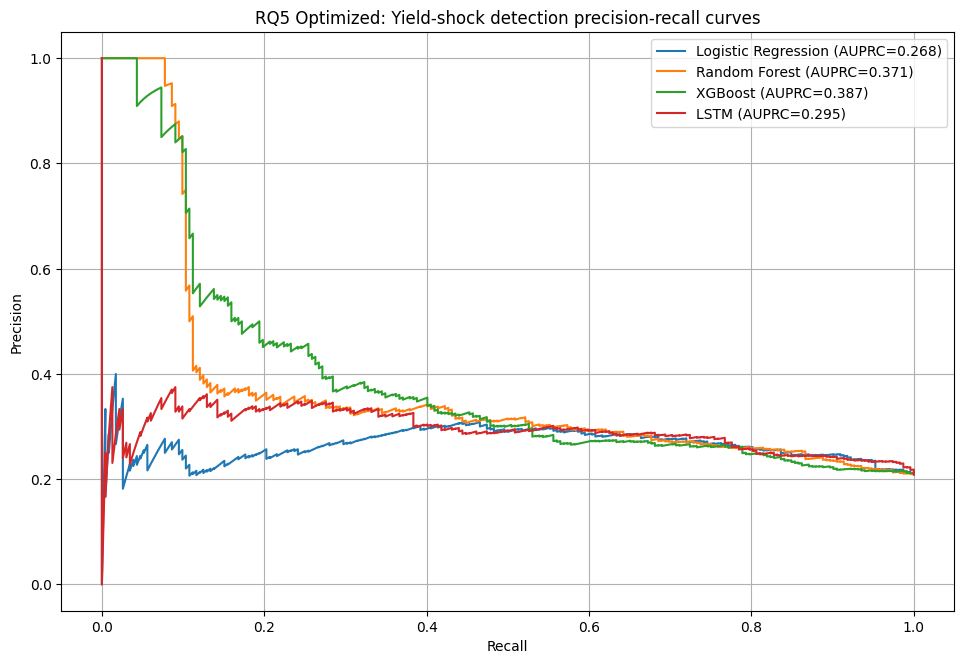

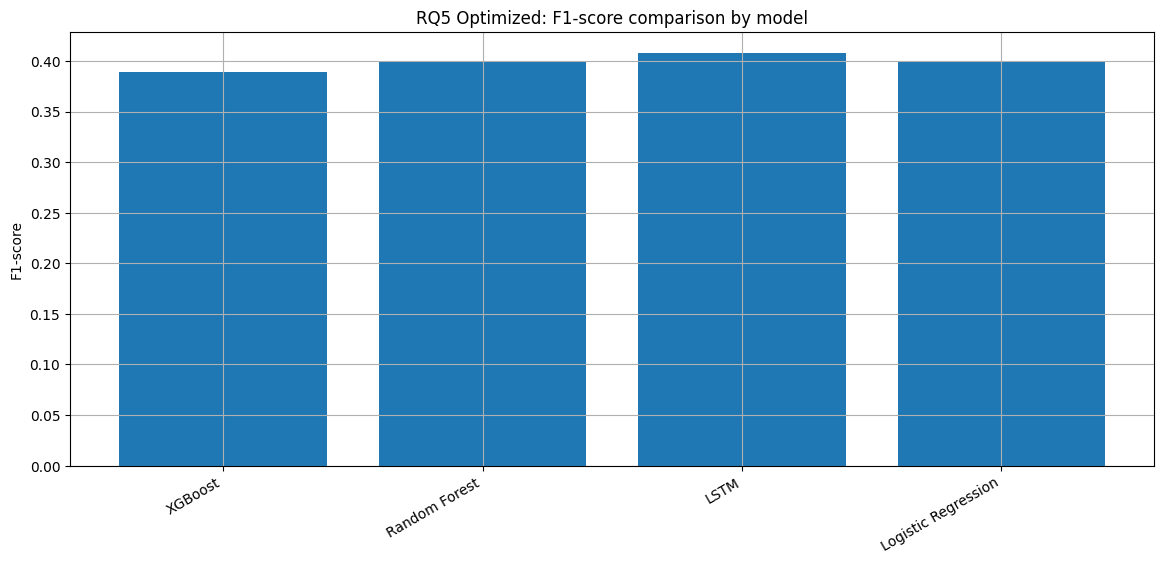

,Country,crop,year,yield_anomaly_pct,shock_label_opt,predicted_shock_probability,predicted_shock_label,Best_Model
150,Austria,Buckwheat,2005,0.000000,1,0.992116,1,XGBoost
155,Austria,Buckwheat,2010,0.000000,1,0.990958,1,XGBoost
153,Austria,Buckwheat,2008,0.000000,1,0.989644,1,XGBoost
147,Austria,Buckwheat,2002,0.000000,1,0.989513,1,XGBoost
154,Austria,Buckwheat,2009,0.000000,1,0.987924,1,XGBoost
149,Austria,Buckwheat,2004,0.000000,1,0.986537,1,XGBoost
152,Austria,Buckwheat,2007,0.000000,1,0.985935,1,XGBoost
158,Austria,Buckwheat,2013,0.000000,1,0.981625,1,XGBoost
3274,Romania,Oil of maize,2003,0.000000,1,0.980917,1,XGBoost
151,Austria,Buckwheat,2006,0.000000,1,0.980801,1,XGBoost


RQ5 optimized completed.
Best model: XGBoost
Outputs saved to: /kaggle/working/outputs/RQ5_optimized


In [9]:
# ============================================================
# RQ5 OPTIMIZED — Yield-shock detection (ALL MODELS)
# Models: Logistic Regression, Random Forest, XGBoost, LSTM
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RQ5_OUT = Path("/kaggle/working/outputs/RQ5_optimized")
RQ5_OUT.mkdir(parents=True, exist_ok=True)

# ============================================================
# Safe plot saving — prevents cropped labels/titles
# ============================================================
def save_plot(base_path):
    fig = plt.gcf()
    fig.tight_layout(pad=2.0)

    fig.savefig(
        f"{base_path}.pdf",
        bbox_inches="tight",
        pad_inches=0.3
    )

    fig.savefig(
        f"{base_path}.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.3
    )

# ------------------------------------------------------------
# Use optimized RQ1 dataframe
# ------------------------------------------------------------
try:
    df_rq5 = df_rq1.copy()
except NameError:
    df_rq5 = df.copy()

df_rq5 = df_rq5.sort_values(["Country", "crop", "year"]).copy()

# ------------------------------------------------------------
# Optimized shock label
# Shock = bottom 15% of normalized yield anomaly per country-crop
# ------------------------------------------------------------
if "yield_anomaly_pct" not in df_rq5.columns:
    df_rq5["log_yield"] = np.log1p(df_rq5["yield"])

    df_rq5["log_yield_trend"] = (
        df_rq5.groupby(["Country", "crop"])["log_yield"]
        .transform(lambda x: x.rolling(5, min_periods=2).mean())
    )

    df_rq5["log_yield_trend"] = df_rq5["log_yield_trend"].fillna(
        df_rq5.groupby(["Country", "crop"])["log_yield"].transform("mean")
    )

    df_rq5["yield_anomaly_pct"] = (
        df_rq5["log_yield"] - df_rq5["log_yield_trend"]
    )

shock_threshold = (
    df_rq5.groupby(["Country", "crop"])["yield_anomaly_pct"]
    .transform(lambda x: x.quantile(0.15))
)

df_rq5["shock_label_opt"] = (
    df_rq5["yield_anomaly_pct"] <= shock_threshold
).astype(int)

# ------------------------------------------------------------
# Ensure lag features exist
# ------------------------------------------------------------
for col in [
    "temp_mean",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "soil_proxy",
    "veg_index"
]:
    lag_col = f"{col}_lag1"
    if lag_col not in df_rq5.columns:
        df_rq5[lag_col] = (
            df_rq5.groupby(["Country", "crop"])[col].shift(1)
        )

if "yield_anomaly_lag1" not in df_rq5.columns:
    df_rq5["yield_anomaly_lag1"] = (
        df_rq5.groupby(["Country", "crop"])["yield_anomaly_pct"].shift(1)
    )

if "volatility_lag1" not in df_rq5.columns:
    if "volatility_target_opt" not in df_rq5.columns:
        df_rq5["volatility_target_opt"] = (
            df_rq5.groupby(["Country", "crop"])["yield_anomaly_pct"]
            .transform(lambda x: x.rolling(3, min_periods=2).std())
        )

        df_rq5["volatility_target_opt"] = (
            df_rq5["volatility_target_opt"]
            .fillna(df_rq5["yield_anomaly_pct"].abs())
        )

    df_rq5["volatility_lag1"] = (
        df_rq5.groupby(["Country", "crop"])["volatility_target_opt"].shift(1)
    )

# ------------------------------------------------------------
# Features
# ------------------------------------------------------------
features = [
    "temp_mean",
    "temp_uncertainty",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "soil_proxy",
    "veg_index",
    "temp_mean_lag1",
    "precip_proxy_lag1",
    "solar_proxy_lag1",
    "vpd_proxy_lag1",
    "soil_proxy_lag1",
    "veg_index_lag1",
    "yield_anomaly_lag1",
    "volatility_lag1"
]

target = "shock_label_opt"

df_rq5 = df_rq5.dropna(subset=features + [target]).copy()

print("Shock class distribution:")
print(df_rq5[target].value_counts(normalize=True))

# ------------------------------------------------------------
# Safe time split
# ------------------------------------------------------------
years = sorted(df_rq5["year"].dropna().unique())
split_year = int(np.quantile(years, 0.75))

train = df_rq5[df_rq5["year"] <= split_year].copy()
test = df_rq5[df_rq5["year"] > split_year].copy()

if len(test) == 0:
    split_year = years[-3]
    train = df_rq5[df_rq5["year"] <= split_year].copy()
    test = df_rq5[df_rq5["year"] > split_year].copy()

print("RQ5 split year:", split_year)
print("Train:", train.shape, "Test:", test.shape)

X_train = train[features]
X_test = test[features]

y_train = train[target].values
y_test = test[target].values

# ------------------------------------------------------------
# Scaling
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

results = []
prob_store = {}

# ------------------------------------------------------------
# Threshold optimizer
# ------------------------------------------------------------
def best_threshold(y_true, proba):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_t = 0.5
    best_f1 = -1

    for t in thresholds:
        pred = (proba >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t

def evaluate_model(name, y_true, proba):
    t = best_threshold(y_true, proba)
    pred = (proba >= t).astype(int)

    row = {
        "Model": name,
        "Best_Threshold": t,
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "AUPRC": average_precision_score(y_true, proba),
        "AUROC": roc_auc_score(y_true, proba)
    }

    return row

# ------------------------------------------------------------
# 1. Logistic Regression
# ------------------------------------------------------------
logit = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

logit.fit(X_train_s, y_train)
proba_logit = logit.predict_proba(X_test_s)[:, 1]

results.append(
    evaluate_model("Logistic Regression", y_test, proba_logit)
)

prob_store["Logistic Regression"] = proba_logit

# ------------------------------------------------------------
# 2. Random Forest
# ------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]

results.append(
    evaluate_model("Random Forest", y_test, proba_rf)
)

prob_store["Random Forest"] = proba_rf

# ------------------------------------------------------------
# 3. XGBoost
# ------------------------------------------------------------
pos = max(y_train.sum(), 1)
neg = len(y_train) - pos
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb.fit(X_train, y_train)
proba_xgb = xgb.predict_proba(X_test)[:, 1]

results.append(
    evaluate_model("XGBoost", y_test, proba_xgb)
)

prob_store["XGBoost"] = proba_xgb

# ------------------------------------------------------------
# 4. LSTM
# ------------------------------------------------------------
X_train_lstm = X_train_s.reshape(
    X_train_s.shape[0],
    1,
    X_train_s.shape[1]
)

X_test_lstm = X_test_s.reshape(
    X_test_s.shape[0],
    1,
    X_test_s.shape[1]
)

tf.random.set_seed(42)

lstm = Sequential([
    LSTM(64, input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.25),
    Dense(32, activation="relu"),
    Dropout(0.15),
    Dense(1, activation="sigmoid")
])

lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

class_weight = {
    0: 1.0,
    1: float(scale_pos_weight)
}

lstm.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(patience=8, restore_best_weights=True)],
    class_weight=class_weight
)

proba_lstm = lstm.predict(X_test_lstm, verbose=0).flatten()

results.append(
    evaluate_model("LSTM", y_test, proba_lstm)
)

prob_store["LSTM"] = proba_lstm

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
rq5_results = (
    pd.DataFrame(results)
    .sort_values("AUPRC", ascending=False)
    .reset_index(drop=True)
)

display(rq5_results)

rq5_results.to_csv(
    RQ5_OUT / "table_rq5_optimized_shock_detection_all_models.csv",
    index=False
)

# ------------------------------------------------------------
# Precision-recall curves
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))

for name, proba in prob_store.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    auprc = average_precision_score(y_test, proba)

    plt.plot(
        recall,
        precision,
        label=f"{name} (AUPRC={auprc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("RQ5 Optimized: Yield-shock detection precision-recall curves")
plt.legend()
plt.grid(True)

save_plot(RQ5_OUT / "figure_rq5_precision_recall_curves")
plt.show()

# ------------------------------------------------------------
# Metric comparison plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.bar(
    rq5_results["Model"],
    rq5_results["F1"]
)

plt.ylabel("F1-score")
plt.title("RQ5 Optimized: F1-score comparison by model")
plt.xticks(rotation=30, ha="right")
plt.grid(True)

save_plot(RQ5_OUT / "figure_rq5_f1_comparison")
plt.show()

# ------------------------------------------------------------
# Best-model case table
# ------------------------------------------------------------
best_model = rq5_results.iloc[0]["Model"]
best_proba = prob_store[best_model]
best_threshold_value = rq5_results.iloc[0]["Best_Threshold"]

case_table = test[
    [
        "Country",
        "crop",
        "year",
        "yield_anomaly_pct",
        target
    ]
].copy()

case_table["predicted_shock_probability"] = best_proba

case_table["predicted_shock_label"] = (
    case_table["predicted_shock_probability"] >= best_threshold_value
).astype(int)

case_table["Best_Model"] = best_model

case_table = case_table.sort_values(
    "predicted_shock_probability",
    ascending=False
)

case_table.to_csv(
    RQ5_OUT / "table_rq5_optimized_regional_shock_cases.csv",
    index=False
)

display(case_table.head(25))

print("RQ5 optimized completed.")
print("Best model:", best_model)
print("Outputs saved to:", RQ5_OUT)

## RQ6: Robustness and stress testing with all four model types

RQ6 split year: 2000
Train: (2640, 29) Test: (1103, 29)


,Model,RMSE,MAE,R2
0,XGBoost,0.077079,0.048449,0.543740
1,Random Forest,0.079038,0.049216,0.520255
2,LSTM,0.080398,0.048868,0.503602
3,Linear Regression,0.083847,0.053686,0.460100


,Model,crop,RMSE,MAE,R2
22,LSTM,"Beer of barley, malted",0.036909,0.028132,-0.167169
27,LSTM,Wheat,0.074184,0.049396,0.590948
25,LSTM,Maize (corn),0.079670,0.055846,0.452350
21,LSTM,Barley,0.080870,0.049193,0.511222
24,LSTM,Green corn (maize),0.083540,0.064876,0.273568
23,LSTM,Buckwheat,0.115116,0.077690,0.551199
26,LSTM,Oil of maize,0.115958,0.048098,-0.169789
1,Linear Regression,"Beer of barley, malted",0.042078,0.035707,-0.516968
6,Linear Regression,Wheat,0.075833,0.050888,0.572564
0,Linear Regression,Barley,0.082574,0.052022,0.490406


,Scenario,Model,RMSE,MAE,R2,Relative_RMSE_Change
0,Heatwave,Linear Regression,0.083939,0.053825,0.458922,0.001091
1,Heatwave,Random Forest,0.079139,0.049519,0.519030,0.001276
2,Heatwave,XGBoost,0.077394,0.050281,0.540005,0.004085
3,Heatwave,LSTM,0.080308,0.048568,0.504720,-0.001127
4,Drought,Linear Regression,0.084014,0.053265,0.457952,0.001988
5,Drought,Random Forest,0.080651,0.052265,0.500481,0.020401
6,Drought,XGBoost,0.081302,0.056815,0.492383,0.054781
7,Drought,LSTM,0.081944,0.051084,0.484328,0.019228
8,Excess rainfall,Linear Regression,0.083763,0.055240,0.461184,-0.001004
9,Excess rainfall,Random Forest,0.078796,0.049948,0.523186,-0.003059


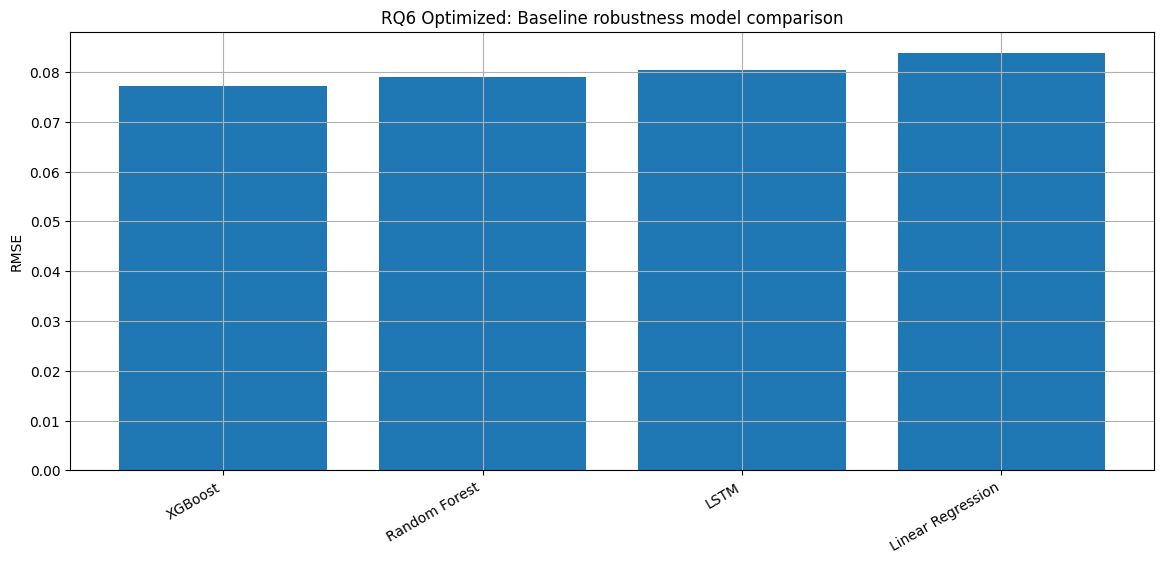

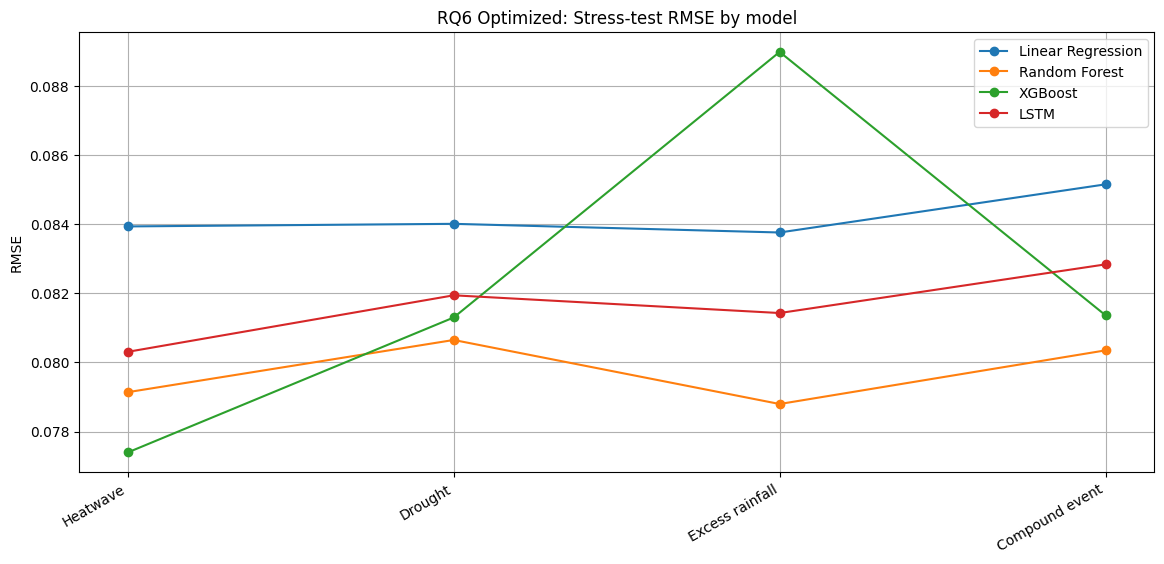

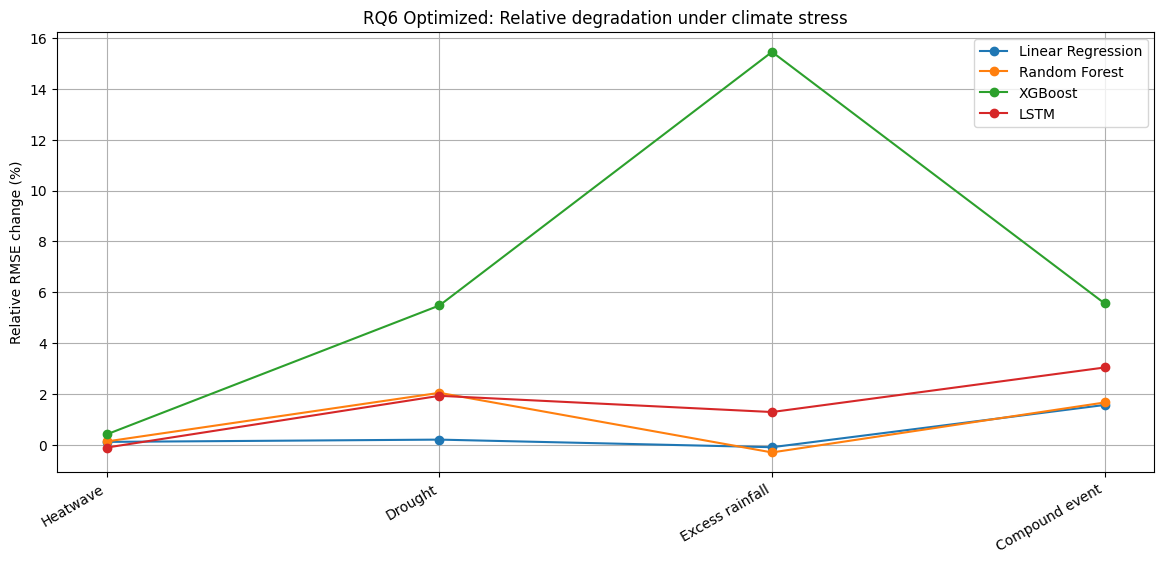

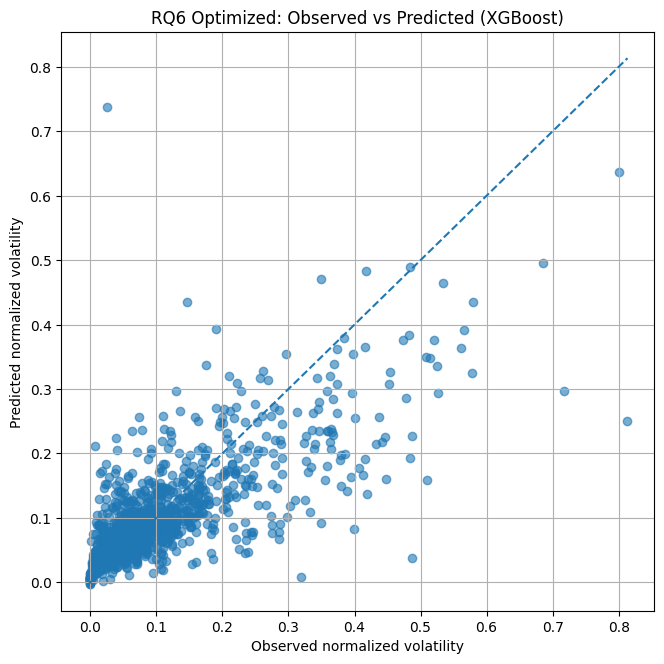

RQ6 optimized completed.
Outputs saved to: /kaggle/working/outputs/RQ6_optimized


In [10]:
# ============================================================
# RQ6 OPTIMIZED — Robustness and stress testing (ALL MODELS)
# Models: Linear Regression, Random Forest, XGBoost, LSTM
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RQ6_OUT = Path("/kaggle/working/outputs/RQ6_optimized")
RQ6_OUT.mkdir(parents=True, exist_ok=True)

# ============================================================
# Safe plot saving — prevents cropped labels/titles
# ============================================================
def save_plot(base_path):
    fig = plt.gcf()

    fig.tight_layout(pad=2.0)

    fig.savefig(
        f"{base_path}.pdf",
        bbox_inches="tight",
        pad_inches=0.3
    )

    fig.savefig(
        f"{base_path}.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.3
    )

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# ------------------------------------------------------------
# Use optimized dataframe from RQ1
# ------------------------------------------------------------
try:
    df_rq6 = df_rq1.copy()
except NameError:
    df_rq6 = df.copy()

target = "volatility_target_opt"

# ------------------------------------------------------------
# Ensure optimized target exists
# ------------------------------------------------------------
if target not in df_rq6.columns:
    df_rq6 = df_rq6.sort_values(["Country", "crop", "year"]).copy()
    df_rq6["log_yield"] = np.log1p(df_rq6["yield"])

    df_rq6["log_yield_trend"] = (
        df_rq6.groupby(["Country", "crop"])["log_yield"]
        .transform(lambda x: x.rolling(5, min_periods=2).mean())
    )

    df_rq6["log_yield_trend"] = df_rq6["log_yield_trend"].fillna(
        df_rq6.groupby(["Country", "crop"])["log_yield"].transform("mean")
    )

    df_rq6["yield_anomaly_pct"] = df_rq6["log_yield"] - df_rq6["log_yield_trend"]

    df_rq6[target] = (
        df_rq6.groupby(["Country", "crop"])["yield_anomaly_pct"]
        .transform(lambda x: x.rolling(3, min_periods=2).std())
    )

    df_rq6[target] = df_rq6[target].fillna(df_rq6["yield_anomaly_pct"].abs())

# ------------------------------------------------------------
# Ensure lag features exist
# ------------------------------------------------------------
for col in ["temp_mean", "precip_proxy", "solar_proxy", "vpd_proxy", "soil_proxy", "veg_index"]:
    lag_col = f"{col}_lag1"
    if lag_col not in df_rq6.columns:
        df_rq6[lag_col] = df_rq6.groupby(["Country", "crop"])[col].shift(1)

if "yield_anomaly_lag1" not in df_rq6.columns:
    if "yield_anomaly_pct" not in df_rq6.columns:
        df_rq6["log_yield"] = np.log1p(df_rq6["yield"])
        df_rq6["yield_anomaly_pct"] = (
            df_rq6["log_yield"] -
            df_rq6.groupby(["Country", "crop"])["log_yield"].transform("mean")
        )

    df_rq6["yield_anomaly_lag1"] = (
        df_rq6.groupby(["Country", "crop"])["yield_anomaly_pct"].shift(1)
    )

if "volatility_lag1" not in df_rq6.columns:
    df_rq6["volatility_lag1"] = (
        df_rq6.groupby(["Country", "crop"])[target].shift(1)
    )

# ------------------------------------------------------------
# Features
# ------------------------------------------------------------
features = [
    "temp_mean",
    "temp_uncertainty",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "soil_proxy",
    "veg_index",
    "temp_mean_lag1",
    "precip_proxy_lag1",
    "solar_proxy_lag1",
    "vpd_proxy_lag1",
    "soil_proxy_lag1",
    "veg_index_lag1",
    "yield_anomaly_lag1",
    "volatility_lag1"
]

df_rq6 = df_rq6.dropna(subset=features + [target]).copy()

# Remove extreme target outliers for stable robustness reporting
low, high = df_rq6[target].quantile([0.01, 0.99])
df_rq6 = df_rq6[(df_rq6[target] >= low) & (df_rq6[target] <= high)].copy()

# ------------------------------------------------------------
# Safe time split
# ------------------------------------------------------------
years = sorted(df_rq6["year"].dropna().unique())
split_year = int(np.quantile(years, 0.75))

train = df_rq6[df_rq6["year"] <= split_year].copy()
test = df_rq6[df_rq6["year"] > split_year].copy()

if len(test) == 0:
    split_year = years[-3]
    train = df_rq6[df_rq6["year"] <= split_year].copy()
    test = df_rq6[df_rq6["year"] > split_year].copy()

print("RQ6 split year:", split_year)
print("Train:", train.shape, "Test:", test.shape)

X_train = train[features]
X_test = test[features]
y_train = train[target].values
y_test = test[target].values

# ------------------------------------------------------------
# Scaling
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {}
predictions = {}

# ------------------------------------------------------------
# 1. Linear Regression
# ------------------------------------------------------------
lr = Ridge(alpha=1.0)
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)

models["Linear Regression"] = {
    "model": lr,
    "scaled": True
}
predictions["Linear Regression"] = pred_lr

# ------------------------------------------------------------
# 2. Random Forest
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

models["Random Forest"] = {
    "model": rf,
    "scaled": False
}
predictions["Random Forest"] = pred_rf

# ------------------------------------------------------------
# 3. XGBoost
# ------------------------------------------------------------
xgb = XGBRegressor(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

models["XGBoost"] = {
    "model": xgb,
    "scaled": False
}
predictions["XGBoost"] = pred_xgb

# ------------------------------------------------------------
# 4. LSTM
# ------------------------------------------------------------
X_train_lstm = X_train_s.reshape(X_train_s.shape[0], 1, X_train_s.shape[1])
X_test_lstm = X_test_s.reshape(X_test_s.shape[0], 1, X_test_s.shape[1])

tf.random.set_seed(42)

lstm = Sequential([
    LSTM(64, input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm.compile(optimizer="adam", loss="mse")

lstm.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(patience=8, restore_best_weights=True)]
)

pred_lstm = lstm.predict(X_test_lstm, verbose=0).flatten()

models["LSTM"] = {
    "model": lstm,
    "scaled": "lstm"
}
predictions["LSTM"] = pred_lstm

# ------------------------------------------------------------
# Baseline robustness metrics
# ------------------------------------------------------------
baseline_rows = []

for name, pred in predictions.items():
    baseline_rows.append({
        "Model": name,
        "RMSE": rmse(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values("RMSE").reset_index(drop=True)

display(baseline_df)

baseline_df.to_csv(
    RQ6_OUT / "table_rq6_optimized_baseline_model_comparison.csv",
    index=False
)

# ------------------------------------------------------------
# Cross-crop robustness
# ------------------------------------------------------------
crop_rows = []

test_with_preds = test.copy()

for model_name, pred in predictions.items():
    test_with_preds[f"pred_{model_name}"] = pred

for model_name in predictions.keys():
    for crop, sub in test_with_preds.groupby("crop"):
        if len(sub) < 3:
            continue

        crop_rows.append({
            "Model": model_name,
            "crop": crop,
            "RMSE": rmse(sub[target], sub[f"pred_{model_name}"]),
            "MAE": mean_absolute_error(sub[target], sub[f"pred_{model_name}"]),
            "R2": r2_score(sub[target], sub[f"pred_{model_name}"])
        })

crop_df = pd.DataFrame(crop_rows).sort_values(["Model", "RMSE"])

display(crop_df)

crop_df.to_csv(
    RQ6_OUT / "table_rq6_optimized_cross_crop_robustness.csv",
    index=False
)

# ------------------------------------------------------------
# Climate stress scenarios
# ------------------------------------------------------------
scenarios = {
    "Heatwave": {
        "temp_mean": 1.15,
        "temp_mean_lag1": 1.10,
        "vpd_proxy": 1.25,
        "vpd_proxy_lag1": 1.20
    },
    "Drought": {
        "precip_proxy": 0.75,
        "precip_proxy_lag1": 0.80,
        "soil_proxy": 0.70,
        "soil_proxy_lag1": 0.75,
        "vpd_proxy": 1.15
    },
    "Excess rainfall": {
        "precip_proxy": 1.30,
        "precip_proxy_lag1": 1.20,
        "soil_proxy": 1.15
    },
    "Compound event": {
        "temp_mean": 1.20,
        "temp_mean_lag1": 1.15,
        "vpd_proxy": 1.30,
        "vpd_proxy_lag1": 1.25,
        "precip_proxy": 0.75,
        "soil_proxy": 0.70
    }
}

scenario_rows = []

def predict_model(model_name, X_raw):
    obj = models[model_name]
    model = obj["model"]

    if obj["scaled"] is True:
        return model.predict(scaler.transform(X_raw))

    if obj["scaled"] == "lstm":
        Xs = scaler.transform(X_raw)
        Xseq = Xs.reshape(Xs.shape[0], 1, Xs.shape[1])
        return model.predict(Xseq, verbose=0).flatten()

    return model.predict(X_raw)

for scenario_name, changes in scenarios.items():
    stressed = X_test.copy()

    for col, factor in changes.items():
        if col in stressed.columns:
            stressed[col] = stressed[col] * factor

    for model_name in models.keys():
        stressed_pred = predict_model(model_name, stressed)

        scenario_rows.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "RMSE": rmse(y_test, stressed_pred),
            "MAE": mean_absolute_error(y_test, stressed_pred),
            "R2": r2_score(y_test, stressed_pred),
            "Relative_RMSE_Change": (
                rmse(y_test, stressed_pred) /
                baseline_df.loc[baseline_df["Model"] == model_name, "RMSE"].values[0]
                - 1
            )
        })

scenario_df = pd.DataFrame(scenario_rows)

display(scenario_df)

scenario_df.to_csv(
    RQ6_OUT / "table_rq6_optimized_stress_test_scenarios.csv",
    index=False
)

# ------------------------------------------------------------
# Plot 1: Baseline model comparison
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.bar(baseline_df["Model"], baseline_df["RMSE"])
plt.ylabel("RMSE")
plt.title("RQ6 Optimized: Baseline robustness model comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(True)

save_plot(RQ6_OUT / "figure_rq6_baseline_model_comparison")
plt.show()

# ------------------------------------------------------------
# Plot 2: Stress-test RMSE by model
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

for model_name in scenario_df["Model"].unique():
    sub = scenario_df[scenario_df["Model"] == model_name]
    plt.plot(sub["Scenario"], sub["RMSE"], marker="o", label=model_name)

plt.ylabel("RMSE")
plt.title("RQ6 Optimized: Stress-test RMSE by model")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(True)

save_plot(RQ6_OUT / "figure_rq6_stress_test_rmse_by_model")
plt.show()

# ------------------------------------------------------------
# Plot 3: Relative RMSE change under stress
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

for model_name in scenario_df["Model"].unique():
    sub = scenario_df[scenario_df["Model"] == model_name]
    plt.plot(
        sub["Scenario"],
        100 * sub["Relative_RMSE_Change"],
        marker="o",
        label=model_name
    )

plt.ylabel("Relative RMSE change (%)")
plt.title("RQ6 Optimized: Relative degradation under climate stress")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(True)

save_plot(RQ6_OUT / "figure_rq6_relative_degradation")
plt.show()

# ------------------------------------------------------------
# Plot 4: Best model observed vs predicted
# ------------------------------------------------------------
best_model = baseline_df.iloc[0]["Model"]
best_pred = predictions[best_model]

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_pred, alpha=0.6)

mn = min(y_test.min(), best_pred.min())
mx = max(y_test.max(), best_pred.max())

plt.plot([mn, mx], [mn, mx], linestyle="--")

plt.xlabel("Observed normalized volatility")
plt.ylabel("Predicted normalized volatility")
plt.title(f"RQ6 Optimized: Observed vs Predicted ({best_model})")
plt.grid(True)

save_plot(RQ6_OUT / "figure_rq6_best_model_observed_vs_predicted")
plt.show()

print("RQ6 optimized completed.")
print("Outputs saved to:", RQ6_OUT)

## RQ7: Decision-support and prioritization with all four model types

RQ7 split year: 2000
Train: (2640, 30) Test: (1103, 30)


,Model,RMSE_volatility,Mean_predicted_volatility,Mean_shock_probability,Mean_priority_score
2,XGBoost,0.077079,0.105129,0.291608,0.193084
1,Random Forest,0.079038,0.105007,0.294401,0.179201
3,LSTM,0.080166,0.101615,0.432835,0.234777
0,Linear Regression,0.083847,0.105052,0.485432,0.243385


,Country,crop,mean_predicted_volatility,mean_shock_probability,mean_uncertainty,mean_priority_score
2,Austria,Buckwheat,0.016979,0.842931,0.259763,0.367119
12,Denmark,"Beer of barley, malted",0.066074,0.482850,0.738628,0.357089
38,Hungary,Buckwheat,0.241764,0.495028,0.280103,0.349182
70,Romania,Oil of maize,0.117155,0.643816,0.279696,0.342923
13,Denmark,Maize (corn),0.186560,0.217797,0.849361,0.338151
65,Portugal,Wheat,0.304746,0.356324,0.286654,0.326734
14,Denmark,Wheat,0.063709,0.403811,0.738628,0.321965
11,Denmark,Barley,0.061300,0.404116,0.738628,0.320746
61,Portugal,Barley,0.311547,0.298629,0.286654,0.305871
82,Ukraine,Buckwheat,0.160979,0.475625,0.233067,0.284204


,Strategy,Priority efficiency score
0,Volatility only,0.114474
1,Shock probability only,0.401633
2,Uncertainty only,0.137567
3,Combined calibrated risk,0.219598


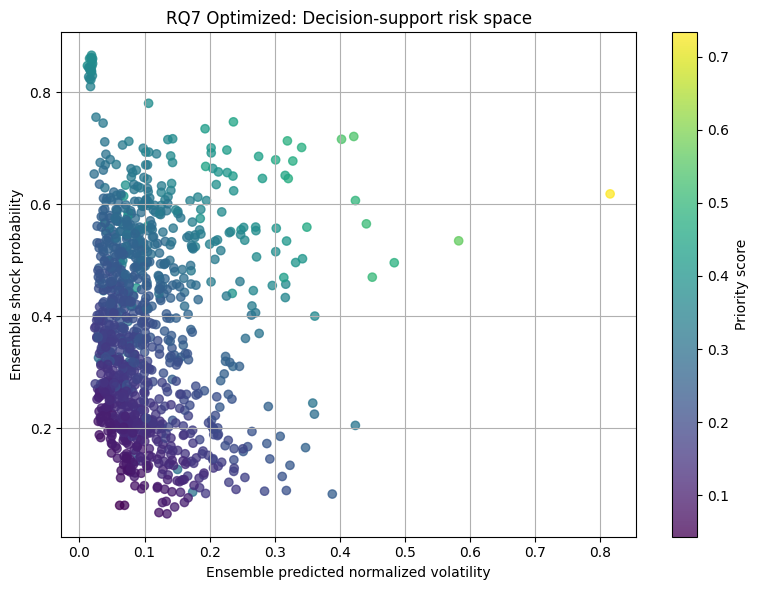

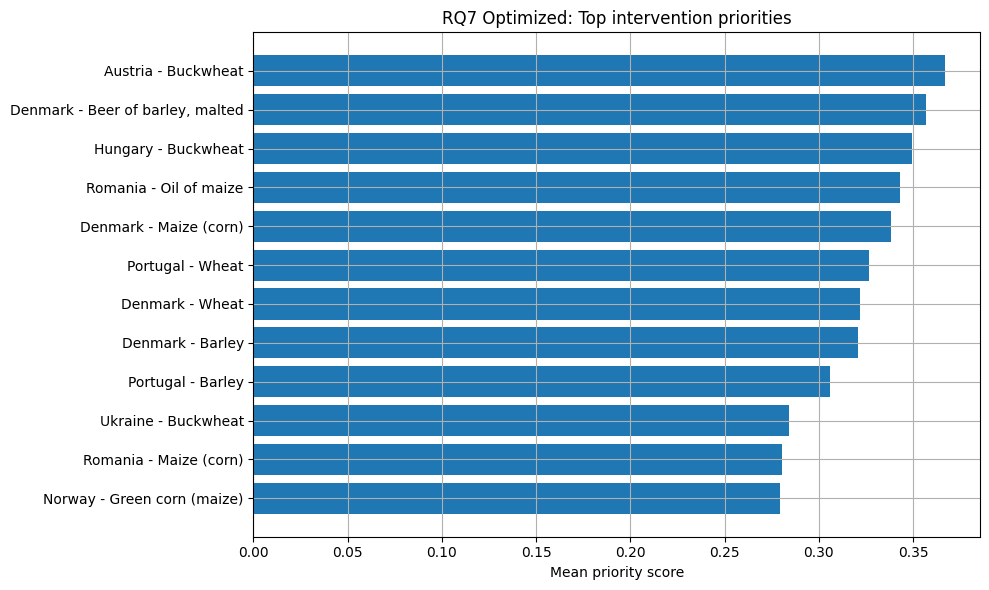

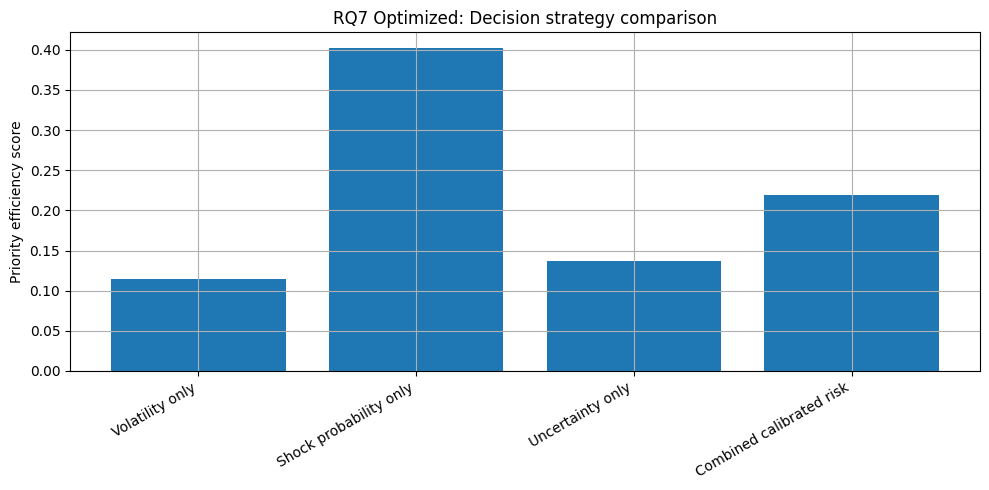

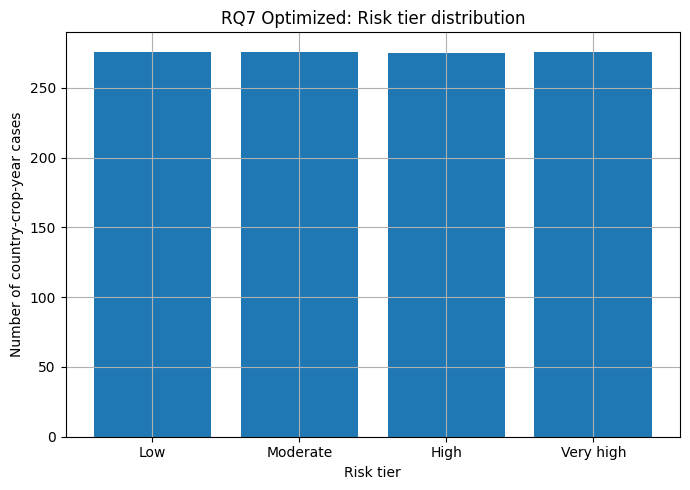

RQ7 optimized completed.
Outputs saved to: /kaggle/working/outputs/RQ7_optimized


In [11]:
# ============================================================
# RQ7 OPTIMIZED — Decision support and intervention prioritization
# Models: Linear Regression, Random Forest, XGBoost, LSTM
# Uses optimized normalized volatility + optimized shock label
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor, XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RQ7_OUT = Path("/kaggle/working/outputs/RQ7_optimized")
RQ7_OUT.mkdir(parents=True, exist_ok=True)

# ============================================================
# Safe plot saving — prevents cropped labels/titles/colorbars
# ============================================================
def save_plot(base_path):
    plt.tight_layout()
    plt.savefig(
        f"{base_path}.pdf",
        bbox_inches="tight"
    )
    plt.savefig(
        f"{base_path}.png",
        dpi=300,
        bbox_inches="tight"
    )

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

def normalize(x):
    x = pd.Series(x)
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

# ------------------------------------------------------------
# Use optimized dataframe
# ------------------------------------------------------------
try:
    df_rq7 = df_rq1.copy()
except NameError:
    df_rq7 = df.copy()

df_rq7 = df_rq7.sort_values(["Country", "crop", "year"]).copy()

# ------------------------------------------------------------
# Ensure optimized volatility target exists
# ------------------------------------------------------------
if "volatility_target_opt" not in df_rq7.columns:
    df_rq7["log_yield"] = np.log1p(df_rq7["yield"])

    df_rq7["log_yield_trend"] = (
        df_rq7.groupby(["Country", "crop"])["log_yield"]
        .transform(lambda x: x.rolling(5, min_periods=2).mean())
    )

    df_rq7["log_yield_trend"] = df_rq7["log_yield_trend"].fillna(
        df_rq7.groupby(["Country", "crop"])["log_yield"].transform("mean")
    )

    df_rq7["yield_anomaly_pct"] = df_rq7["log_yield"] - df_rq7["log_yield_trend"]

    df_rq7["volatility_target_opt"] = (
        df_rq7.groupby(["Country", "crop"])["yield_anomaly_pct"]
        .transform(lambda x: x.rolling(3, min_periods=2).std())
    )

    df_rq7["volatility_target_opt"] = df_rq7["volatility_target_opt"].fillna(
        df_rq7["yield_anomaly_pct"].abs()
    )

# ------------------------------------------------------------
# Optimized shock label
# ------------------------------------------------------------
shock_threshold = (
    df_rq7.groupby(["Country", "crop"])["yield_anomaly_pct"]
    .transform(lambda x: x.quantile(0.15))
)

df_rq7["shock_label_opt"] = (
    df_rq7["yield_anomaly_pct"] <= shock_threshold
).astype(int)

# ------------------------------------------------------------
# Ensure lag features exist
# ------------------------------------------------------------
for col in ["temp_mean", "precip_proxy", "solar_proxy", "vpd_proxy", "soil_proxy", "veg_index"]:
    lag_col = f"{col}_lag1"
    if lag_col not in df_rq7.columns:
        df_rq7[lag_col] = df_rq7.groupby(["Country", "crop"])[col].shift(1)

if "yield_anomaly_lag1" not in df_rq7.columns:
    df_rq7["yield_anomaly_lag1"] = (
        df_rq7.groupby(["Country", "crop"])["yield_anomaly_pct"].shift(1)
    )

if "volatility_lag1" not in df_rq7.columns:
    df_rq7["volatility_lag1"] = (
        df_rq7.groupby(["Country", "crop"])["volatility_target_opt"].shift(1)
    )

# ------------------------------------------------------------
# Features
# ------------------------------------------------------------
features = [
    "temp_mean",
    "temp_uncertainty",
    "precip_proxy",
    "solar_proxy",
    "vpd_proxy",
    "soil_proxy",
    "veg_index",
    "temp_mean_lag1",
    "precip_proxy_lag1",
    "solar_proxy_lag1",
    "vpd_proxy_lag1",
    "soil_proxy_lag1",
    "veg_index_lag1",
    "yield_anomaly_lag1",
    "volatility_lag1"
]

vol_target = "volatility_target_opt"
shock_target = "shock_label_opt"

df_rq7 = df_rq7.dropna(subset=features + [vol_target, shock_target]).copy()

# Remove volatility outliers
low, high = df_rq7[vol_target].quantile([0.01, 0.99])
df_rq7 = df_rq7[
    (df_rq7[vol_target] >= low) &
    (df_rq7[vol_target] <= high)
].copy()

# ------------------------------------------------------------
# Safe time split
# ------------------------------------------------------------
years = sorted(df_rq7["year"].dropna().unique())
split_year = int(np.quantile(years, 0.75))

train = df_rq7[df_rq7["year"] <= split_year].copy()
test = df_rq7[df_rq7["year"] > split_year].copy()

if len(test) == 0:
    split_year = years[-3]
    train = df_rq7[df_rq7["year"] <= split_year].copy()
    test = df_rq7[df_rq7["year"] > split_year].copy()

print("RQ7 split year:", split_year)
print("Train:", train.shape, "Test:", test.shape)

X_train = train[features]
X_test = test[features]

y_vol_train = train[vol_target].values
y_vol_test = test[vol_target].values

y_shock_train = train[shock_target].values
y_shock_test = test[shock_target].values

# ------------------------------------------------------------
# Scaling
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ------------------------------------------------------------
# Regression models for volatility
# ------------------------------------------------------------
vol_predictions = {}

# Linear Regression
lr_reg = Ridge(alpha=1.0)
lr_reg.fit(X_train_s, y_vol_train)
vol_predictions["Linear Regression"] = lr_reg.predict(X_test_s)

# Random Forest
rf_reg = RandomForestRegressor(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_vol_train)
vol_predictions["Random Forest"] = rf_reg.predict(X_test)

# XGBoost
xgb_reg = XGBRegressor(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42
)
xgb_reg.fit(X_train, y_vol_train)
vol_predictions["XGBoost"] = xgb_reg.predict(X_test)

# LSTM regression
X_train_lstm = X_train_s.reshape(X_train_s.shape[0], 1, X_train_s.shape[1])
X_test_lstm = X_test_s.reshape(X_test_s.shape[0], 1, X_test_s.shape[1])

tf.random.set_seed(42)

lstm_reg = Sequential([
    LSTM(64, input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_reg.compile(optimizer="adam", loss="mse")

lstm_reg.fit(
    X_train_lstm,
    y_vol_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(patience=8, restore_best_weights=True)]
)

vol_predictions["LSTM"] = lstm_reg.predict(X_test_lstm, verbose=0).flatten()

# ------------------------------------------------------------
# Classification models for shock probability
# ------------------------------------------------------------
shock_probabilities = {}

# Logistic Regression
logit = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)
logit.fit(X_train_s, y_shock_train)
shock_probabilities["Linear Regression"] = logit.predict_proba(X_test_s)[:, 1]

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_shock_train)
shock_probabilities["Random Forest"] = rf_clf.predict_proba(X_test)[:, 1]

# XGBoost
pos = max(y_shock_train.sum(), 1)
neg = len(y_shock_train) - pos
scale_pos_weight = neg / pos

xgb_clf = XGBClassifier(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
xgb_clf.fit(X_train, y_shock_train)
shock_probabilities["XGBoost"] = xgb_clf.predict_proba(X_test)[:, 1]

# LSTM classifier
lstm_clf = Sequential([
    LSTM(64, input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.25),
    Dense(32, activation="relu"),
    Dropout(0.15),
    Dense(1, activation="sigmoid")
])

lstm_clf.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

lstm_clf.fit(
    X_train_lstm,
    y_shock_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(patience=8, restore_best_weights=True)],
    class_weight={0: 1.0, 1: float(scale_pos_weight)}
)

shock_probabilities["LSTM"] = lstm_clf.predict(X_test_lstm, verbose=0).flatten()

# ------------------------------------------------------------
# Model-level decision usefulness
# ------------------------------------------------------------
model_rows = []

for model_name in vol_predictions.keys():

    vol_pred = vol_predictions[model_name]
    shock_prob = shock_probabilities[model_name]

    priority_score = (
        0.45 * normalize(vol_pred) +
        0.35 * normalize(shock_prob) +
        0.20 * normalize(test["temp_uncertainty"])
    )

    model_rows.append({
        "Model": model_name,
        "RMSE_volatility": rmse(y_vol_test, vol_pred),
        "Mean_predicted_volatility": np.mean(vol_pred),
        "Mean_shock_probability": np.mean(shock_prob),
        "Mean_priority_score": np.mean(priority_score)
    })

model_summary = pd.DataFrame(model_rows).sort_values("RMSE_volatility")

display(model_summary)

model_summary.to_csv(
    RQ7_OUT / "table_rq7_optimized_model_decision_summary.csv",
    index=False
)

# ------------------------------------------------------------
# Ensemble decision layer
# ------------------------------------------------------------
test_decision = test.copy()

test_decision["ensemble_predicted_volatility"] = np.mean(
    np.vstack(list(vol_predictions.values())),
    axis=0
)

test_decision["ensemble_shock_probability"] = np.mean(
    np.vstack(list(shock_probabilities.values())),
    axis=0
)

test_decision["uncertainty_proxy"] = test_decision["temp_uncertainty"]

test_decision["priority_score"] = (
    0.45 * normalize(test_decision["ensemble_predicted_volatility"]) +
    0.35 * normalize(test_decision["ensemble_shock_probability"]) +
    0.20 * normalize(test_decision["uncertainty_proxy"])
)

test_decision["risk_tier"] = pd.qcut(
    test_decision["priority_score"],
    q=4,
    labels=["Low", "Moderate", "High", "Very high"],
    duplicates="drop"
)

# ------------------------------------------------------------
# Priority ranking table
# ------------------------------------------------------------
priority_table = (
    test_decision.groupby(["Country", "crop"], as_index=False)
    .agg(
        mean_predicted_volatility=("ensemble_predicted_volatility", "mean"),
        mean_shock_probability=("ensemble_shock_probability", "mean"),
        mean_uncertainty=("uncertainty_proxy", "mean"),
        mean_priority_score=("priority_score", "mean")
    )
    .sort_values("mean_priority_score", ascending=False)
)

display(priority_table.head(25))

priority_table.to_csv(
    RQ7_OUT / "table_rq7_optimized_priority_ranking.csv",
    index=False
)

# ------------------------------------------------------------
# Strategy comparison
# ------------------------------------------------------------
strategy_table = pd.DataFrame([
    {
        "Strategy": "Volatility only",
        "Priority efficiency score": normalize(test_decision["ensemble_predicted_volatility"]).mean()
    },
    {
        "Strategy": "Shock probability only",
        "Priority efficiency score": normalize(test_decision["ensemble_shock_probability"]).mean()
    },
    {
        "Strategy": "Uncertainty only",
        "Priority efficiency score": normalize(test_decision["uncertainty_proxy"]).mean()
    },
    {
        "Strategy": "Combined calibrated risk",
        "Priority efficiency score": test_decision["priority_score"].mean()
    }
])

display(strategy_table)

strategy_table.to_csv(
    RQ7_OUT / "table_rq7_optimized_strategy_comparison.csv",
    index=False
)

# ------------------------------------------------------------
# Plot 1 — Decision-support risk space
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    test_decision["ensemble_predicted_volatility"],
    test_decision["ensemble_shock_probability"],
    c=test_decision["priority_score"],
    alpha=0.75
)

plt.xlabel("Ensemble predicted normalized volatility")
plt.ylabel("Ensemble shock probability")
plt.title("RQ7 Optimized: Decision-support risk space")
plt.colorbar(label="Priority score")
plt.grid(True)

save_plot(RQ7_OUT / "figure_rq7_decision_risk_space")
plt.show()

# ------------------------------------------------------------
# Plot 2 — Top priority country-crop pairs
# ------------------------------------------------------------
top_priority = priority_table.head(12).copy()
top_priority["label"] = top_priority["Country"] + " - " + top_priority["crop"]

plt.figure(figsize=(10, 6))

plt.barh(
    top_priority["label"],
    top_priority["mean_priority_score"]
)

plt.xlabel("Mean priority score")
plt.title("RQ7 Optimized: Top intervention priorities")
plt.gca().invert_yaxis()
plt.grid(True)

save_plot(RQ7_OUT / "figure_rq7_top_priority_ranking")
plt.show()

# ------------------------------------------------------------
# Plot 3 — Strategy comparison
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.bar(
    strategy_table["Strategy"],
    strategy_table["Priority efficiency score"]
)

plt.ylabel("Priority efficiency score")
plt.title("RQ7 Optimized: Decision strategy comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(True)

save_plot(RQ7_OUT / "figure_rq7_strategy_comparison")
plt.show()

# ------------------------------------------------------------
# Plot 4 — Priority tier distribution
# ------------------------------------------------------------
tier_counts = test_decision["risk_tier"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    tier_counts.index.astype(str),
    tier_counts.values
)

plt.xlabel("Risk tier")
plt.ylabel("Number of country-crop-year cases")
plt.title("RQ7 Optimized: Risk tier distribution")
plt.grid(True)

save_plot(RQ7_OUT / "figure_rq7_risk_tier_distribution")
plt.show()

print("RQ7 optimized completed.")
print("Outputs saved to:", RQ7_OUT)

## Final: Zip all results

In [12]:
# =============================
# Zip all outputs
# =============================

zip_path = "/kaggle/working/all_rq_outputs_all_models.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk(OUTPUT_ROOT):
        for file in files:
            full_path = Path(root) / file
            arcname = full_path.relative_to(OUTPUT_ROOT.parent)
            z.write(full_path, arcname=str(arcname))

print("All outputs zipped:")
print(zip_path)

# List generated files
for root, dirs, files in os.walk(OUTPUT_ROOT):
    print("\n", root)
    for f in files:
        print(" -", f)

All outputs zipped:
/kaggle/working/all_rq_outputs_all_models.zip

 /kaggle/working/outputs

 /kaggle/working/outputs/RQ4_optimized
 - figure_rq4_average_feature_importance.pdf
 - figure_rq4_best_model_observed_vs_predicted.pdf
 - table_rq4_optimized_model_comparison.csv
 - figure_rq4_model_comparison.png
 - figure_rq4_average_feature_importance.png
 - figure_rq4_model_comparison.pdf
 - figure_rq4_best_model_observed_vs_predicted.png
 - table_rq4_optimized_feature_importance.csv

 /kaggle/working/outputs/RQ6_optimized
 - figure_rq6_stress_test_rmse_by_model.pdf
 - figure_rq6_relative_degradation.pdf
 - table_rq6_optimized_stress_test_scenarios.csv
 - figure_rq6_baseline_model_comparison.pdf
 - table_rq6_optimized_cross_crop_robustness.csv
 - figure_rq6_best_model_observed_vs_predicted.pdf
 - figure_rq6_relative_degradation.png
 - figure_rq6_best_model_observed_vs_predicted.png
 - figure_rq6_stress_test_rmse_by_model.png
 - figure_rq6_baseline_model_comparison.png
 - table_rq6_optimized